## Matt note

A 7-, 14- or 30-day path is **not** one model rolled forward.

There is a separately tuned XGBoost for every lead h = 1, 2, ..., 30 (best 1-day model, best 2-day model, and so on). Each model predicts only day t+h from features known at origin t.

The pooled-path score **stitches** those specialists: from the same start date, take the 1-day forecast for t+1, the 2-day forecast for t+2, up to t+H. That is direct multi-horizon forecasting. The 1-day model is never fed back to make day 2.

The neural notebooks are different: one multi-output network per H, trained on the whole path at once.


> **Copy note.** This notebook is a copy of `XG Boost-2.ipynb`. The code now trains a direct model for every lead 1…30 and reports pooled-path test metrics at 7, 14 and 30 days so they can be compared with the neural notebooks. The markdown below is still the original four-horizon write-up and will need editing. Stale cells have a note at the bottom. Code edits are marked with `# Changed:`.

> **Matt note.** A 7-, 14- or 30-day path is **not** one model rolled forward. There is a separately tuned XGBoost for every lead h = 1, 2, ..., 30 (best 1-day model, best 2-day model, ...). Each model predicts only day t+h from features known at origin t. The pooled-path score **stitches** those specialists: from the same start date, take the 1-day forecast for t+1, the 2-day forecast for t+2, ..., up to t+H. That is *direct* multi-horizon forecasting. The 1-day model is never fed back to make day 2. The neural notebooks are different: one multi-output network per H, trained on the whole path at once.

# XGBoost Multi-Horizon PM₂.₅ Forecasting

## London Marylebone Road

This notebook evaluates an XGBoost regression approach for direct multi-horizon daily PM₂.₅ forecasting at **1-, 7-, 14-, and 30-day lead times**.

The experimental design preserves the temporal ordering of the data. Models are trained using historical observations up to the end of 2024 and evaluated on unseen observations from 2025. Hyperparameters are selected using time-series cross-validation with a horizon-specific gap to reduce temporal overlap between training and validation targets.

### Evaluation framework

Model performance is assessed using:

- **MAE** — Mean Absolute Error
- **MSE** — Mean Squared Error
- **RMSE** — Root Mean Squared Error
- **R²** — coefficient of determination
- **MAPE** — Mean Absolute Percentage Error
- **MBE** — Mean Bias Error

A **persistence baseline** is evaluated using the same target dates and metrics. For a forecast originating at time *t*, persistence assumes that the future PM₂.₅ concentration remains equal to the observed concentration at *t*.

Permutation importance is also used as a post-hoc interpretability method to investigate how predictor relevance changes with forecast horizon.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [22]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

In [23]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

DATA_DIR = Path("../data/splits/")

TARGET = "pm25"

DROP_COLS = ["date", TARGET]

MODEL_DIR = Path("saved_con_xgb")
MODEL_DIR.mkdir(exist_ok=True)

RESULTS_DIR = Path("xgb_results_path")
RESULTS_DIR.mkdir(exist_ok=True)

# Changed: direct model for every lead 1..30 (was [1, 7, 14, 30]).
FORECAST_HORIZONS = list(range(1, 31))
# Changed: pooled-path lengths that match the neural notebooks.
PATH_HORIZONS = [7, 14, 30]

RANDOM_STATE = 42


In [24]:
# ============================================================
# 3. DATASET PATHS
# ============================================================

TRAIN_PATH = DATA_DIR / "marylebone_train.csv"
TEST_PATH = DATA_DIR / "marylebone_test.csv"
ALL_PATH = DATA_DIR / "marylebone_all.csv"

print("Train:", TRAIN_PATH)
print("Test :", TEST_PATH)
print("All  :", ALL_PATH)

print("\nFiles found:")
print("Train:", TRAIN_PATH.exists())
print("Test :", TEST_PATH.exists())
print("All  :", ALL_PATH.exists())

Train: ../data/splits/marylebone_train.csv
Test : ../data/splits/marylebone_test.csv
All  : ../data/splits/marylebone_all.csv

Files found:
Train: True
Test : True
All  : True


In [25]:
# ============================================================
# 4. LOAD AND PREPARE DATA
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
df = pd.read_csv(ALL_PATH)

for dataset in [train_df, test_df, df]:
    dataset["date"] = pd.to_datetime(dataset["date"])
    dataset.sort_values("date", inplace=True)
    dataset.reset_index(drop=True, inplace=True)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Full shape :", df.shape)

print("\nTraining period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())

Train shape: (1000, 42)
Test shape : (364, 42)
Full shape : (1364, 42)

Training period:
2022-04-07 00:00:00 to 2024-12-31 00:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-30 00:00:00


In [26]:
# ============================================================
# 5. TRAIN / TEST BOUNDARIES
# ============================================================

TRAIN_END = train_df["date"].max()
TEST_START = test_df["date"].min()
TEST_END = test_df["date"].max()

print("Train end :", TRAIN_END)
print("Test start:", TEST_START)
print("Test end  :", TEST_END)

Train end : 2024-12-31 00:00:00
Test start: 2025-01-01 00:00:00
Test end  : 2025-12-30 00:00:00


In [27]:
# ============================================================
# 6. FEATURES
# ============================================================

features = [
    col
    for col in df.columns
    if col not in DROP_COLS
]

print("Number of features:", len(features))

for feature in features:
    print(feature)

Number of features: 40
year
month
day_of_month
day_of_week_x
day_of_year
week_of_year
quarter
is_weekend
is_weekday
season_code
month_sin
month_cos
doy_sin
doy_cos
dow_sin
dow_cos
week_sin
week_cos
pm25_lag1
pm25_lag7
pm25_rollmean3
pm25_rollstd3
day_of_week_y
quarter_num
mean_relative_humidity_pct
relative_humidity_max_pct
relative_humidity_min_pct
total_precipitation_mm
precipitation_max_mm
precipitation_min_mm
mean_air_pressure_hpa
air_pressure_max_hpa
air_pressure_min_hpa
temperature_max_c
temperature_min_c
temperature_avg_c
mean_wind_speed_knots
wind_speed_max_knots
wind_speed_min_knots
wind_direction_deg


In [28]:
# ============================================================
# 7. XGBOOST HYPERPARAMETER SEARCH SPACE
# ============================================================

PARAM_GRID = {
    "n_estimators": [200, 300, 500, 700],

    "max_depth": [2, 3, 4, 5, 6],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.8,
        1.0
    ],

    "min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "gamma": [
        0,
        0.05,
        0.1,
        0.2
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1.0
    ],

    "reg_lambda": [
        0.5,
        1.0,
        2.0,
        5.0
    ]
}

print("XGBoost parameter grid ready.")

XGBoost parameter grid ready.


## XGBoost Multi-Horizon Modelling

A separate XGBoost model is trained for each forecast horizon. The target for horizon \(h\) is defined as the observed PM₂.₅ concentration at \(t+h\).

For each horizon:

1. The future target is created by shifting PM₂.₅ by the required lead time.
2. Training samples are restricted so that both the forecast origin and target remain within the training period.
3. Evaluation samples are restricted to the unseen 2025 test period.
4. Hyperparameters are optimised using five-fold `TimeSeriesSplit`.
5. A gap equal to the forecast horizon is used between training and validation folds.
6. The selected model is compared with a persistence forecast on identical target observations.

This design allows forecast performance to be investigated as the prediction lead time increases.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [29]:
# ============================================================
# XGBOOST MULTI-HORIZON MODELLING
# Changed: FORECAST_HORIZONS is now 1..30 so a path [t+1, ..., t+H]
# can be assembled. Each model is still a direct day-h forecast.
# Pooled-path scores are computed after this loop.
# ============================================================

results = []
best_models = {}
predictions = {}
feature_importances = {}

for horizon in FORECAST_HORIZONS:

    print("\n" + "=" * 75)
    print(f"XGBOOST — {horizon}-DAY-AHEAD PM2.5 FORECAST")
    print("=" * 75)

    # --------------------------------------------------------
    # DATA FOR THIS HORIZON
    # --------------------------------------------------------

    data = df.copy()

    target_col = f"target_pm25_{horizon}d"
    target_date_col = f"target_date_{horizon}d"

    data[target_col] = data[TARGET].shift(-horizon)
    data[target_date_col] = data["date"].shift(-horizon)

    data = data.dropna(
        subset=[target_col, target_date_col]
    ).copy()

    # --------------------------------------------------------
    # TRAINING DATA
    # --------------------------------------------------------

    train_data = data[
        (data["date"] <= TRAIN_END)
        &
        (data[target_date_col] <= TRAIN_END)
    ].copy()

    # --------------------------------------------------------
    # TEST DATA
    # --------------------------------------------------------

    test_data = data[
        (data["date"] >= TEST_START)
        &
        (data["date"] <= TEST_END)
        &
        (data[target_date_col] <= TEST_END)
    ].copy()

    X_train = train_data[features].copy()
    y_train = train_data[target_col].copy()

    X_test = test_data[features].copy()
    y_test = test_data[target_col].copy()

    print(
        f"Training observations: {len(X_train)}"
    )

    print(
        f"Testing observations : {len(X_test)}"
    )

    # --------------------------------------------------------
    # TIME SERIES CROSS-VALIDATION
    # --------------------------------------------------------

    tscv = TimeSeriesSplit(
        n_splits=5,
        gap=horizon
    )

    # --------------------------------------------------------
    # XGBOOST BASE MODEL
    # --------------------------------------------------------

    base_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    # --------------------------------------------------------
    # HYPERPARAMETER OPTIMISATION
    # --------------------------------------------------------

    search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=PARAM_GRID,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(
        X_train,
        y_train
    )

    best_xgb = search.best_estimator_

    best_models[horizon] = best_xgb

    cv_mae = -search.best_score_

    print("\nBest Parameters:")
    print(search.best_params_)

    print(
        f"Cross-validation MAE: {cv_mae:.4f}"
    )

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    y_pred = best_xgb.predict(
        X_test
    )

    y_true = y_test.to_numpy()

    # --------------------------------------------------------
    # XGBOOST EVALUATION METRICS
    # --------------------------------------------------------

    # Mean Absolute Error
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # Mean Squared Error
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    # Root Mean Squared Error
    rmse = np.sqrt(
        mse
    )

    # R-squared
    r2 = r2_score(
        y_true,
        y_pred
    )

    # Mean Absolute Percentage Error
    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred)
                / np.maximum(
                    np.abs(y_true),
                    1e-8
                )
            )
        ) * 100
    )

    # Mean Bias Error
    # Positive = overprediction
    # Negative = underprediction
    mbe = np.mean(
        y_pred - y_true
    )

    # --------------------------------------------------------
    # PERSISTENCE BASELINE
    # --------------------------------------------------------

    persistence_pred = (
        test_data[TARGET]
        .to_numpy()
    )

    persistence_mae = mean_absolute_error(
        y_true,
        persistence_pred
    )

    persistence_mse = mean_squared_error(
        y_true,
        persistence_pred
    )

    persistence_rmse = np.sqrt(
        persistence_mse
    )

    persistence_r2 = r2_score(
        y_true,
        persistence_pred
    )

    persistence_mape = (
        np.mean(
            np.abs(
                (y_true - persistence_pred)
                / np.maximum(
                    np.abs(y_true),
                    1e-8
                )
            )
        ) * 100
    )

    persistence_mbe = np.mean(
        persistence_pred - y_true
    )

    # --------------------------------------------------------
    # IMPROVEMENT OVER PERSISTENCE BASELINE
    # --------------------------------------------------------

    mae_improvement = (
        (persistence_mae - mae)
        / persistence_mae
    ) * 100

    rmse_improvement = (
        (persistence_rmse - rmse)
        / persistence_rmse
    ) * 100

    # --------------------------------------------------------
    # DISPLAY XGBOOST PERFORMANCE
    # --------------------------------------------------------

    print("\nXGBoost Performance")
    print("-" * 50)

    print(f"MAE  = {mae:.4f}")
    print(f"MSE  = {mse:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")
    print(f"MAPE = {mape:.2f}%")
    print(f"MBE  = {mbe:.4f}")

    # --------------------------------------------------------
    # DISPLAY PERSISTENCE PERFORMANCE
    # --------------------------------------------------------

    print("\nPersistence Baseline")
    print("-" * 50)

    print(f"MAE  = {persistence_mae:.4f}")
    print(f"MSE  = {persistence_mse:.4f}")
    print(f"RMSE = {persistence_rmse:.4f}")
    print(f"R²   = {persistence_r2:.4f}")
    print(f"MAPE = {persistence_mape:.2f}%")
    print(f"MBE  = {persistence_mbe:.4f}")

    print("\nImprovement Over Persistence")
    print("-" * 50)

    print(
        f"MAE improvement  = "
        f"{mae_improvement:.2f}%"
    )

    print(
        f"RMSE improvement = "
        f"{rmse_improvement:.2f}%"
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    results.append({
        "Horizon_Days": horizon,
        "Model": "XGBoost",

        "Training_Observations":
            len(X_train),

        "Testing_Observations":
            len(X_test),

        "CV_MAE": cv_mae,

        # XGBoost metrics
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "MBE": mbe,

        # Persistence baseline metrics
        "Persistence_MAE":
            persistence_mae,

        "Persistence_MSE":
            persistence_mse,

        "Persistence_RMSE":
            persistence_rmse,

        "Persistence_R2":
            persistence_r2,

        "Persistence_MAPE":
            persistence_mape,

        "Persistence_MBE":
            persistence_mbe,

        # Improvement over persistence
        "MAE_Improvement_Percent":
            mae_improvement,

        "RMSE_Improvement_Percent":
            rmse_improvement
    })

    # --------------------------------------------------------
    # SAVE PREDICTIONS
    # --------------------------------------------------------

    pred_df = pd.DataFrame({
        "Forecast_Origin":
            test_data["date"].to_numpy(),

        "Target_Date":
            test_data[target_date_col].to_numpy(),

        "Actual_PM25":
            y_true,

        "Predicted_PM25":
            y_pred,

        "Persistence_PM25":
            persistence_pred,

        # Actual - predicted
        "Residual":
            y_true - y_pred
    })

    predictions[horizon] = pred_df

    pred_df.to_csv(
        RESULTS_DIR
        / f"xgb_predictions_{horizon}d.csv",
        index=False
    )

    # --------------------------------------------------------
    # PERMUTATION IMPORTANCE
    # --------------------------------------------------------

    perm = permutation_importance(
        best_xgb,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "Feature":
            features,

        "Importance_Mean":
            perm.importances_mean,

        "Importance_STD":
            perm.importances_std
    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance_Mean",
            ascending=False
        )
        .reset_index(drop=True)
    )

    feature_importances[horizon] = (
        importance_df
    )

    # --------------------------------------------------------
    # SAVE MODEL
    # --------------------------------------------------------

    best_xgb.save_model(
        MODEL_DIR
        / f"xgboost_{horizon}d.json"
    )

    joblib.dump(
        best_xgb,
        MODEL_DIR
        / f"xgboost_{horizon}d.joblib"
    )

    print(
        f"\n✓ {horizon}-day model completed."
    )



XGBOOST — 1-DAY-AHEAD PM2.5 FORECAST
Training observations: 999
Testing observations : 363
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Cross-validation MAE: 2.8048

XGBoost Performance
--------------------------------------------------
MAE  = 3.1553
MSE  = 26.7617
RMSE = 5.1732
R²   = 0.4797
MAPE = 40.90%
MBE  = -0.0220

Persistence Baseline
--------------------------------------------------
MAE  = 3.1241
MSE  = 32.1905
RMSE = 5.6737
R²   = 0.3742
MAPE = 37.64%
MBE  = 0.0003

Improvement Over Persistence
--------------------------------------------------
MAE improvement  = -1.00%
RMSE improvement = 8.82%

✓ 1-day model completed.

XGBOOST — 2-DAY-AHEAD PM2.5 FORECAST
Training observations: 998
Testing observations : 362
Fitting 5 folds for each of 30 candidates, totalling 15

In [30]:
# ============================================================
# FINAL XGBOOST RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = (
    results_df
    .sort_values(
        "Horizon_Days"
    )
    .reset_index(
        drop=True
    )
)

display(
    results_df.round(4)
)

,Horizon_Days,Model,Training_Observations,Testing_Observations,CV_MAE,MAE,MSE,RMSE,R2,MAPE,MBE,Persistence_MAE,Persistence_MSE,Persistence_RMSE,Persistence_R2,Persistence_MAPE,Persistence_MBE,MAE_Improvement_Percent,RMSE_Improvement_Percent
0,1,XGBoost,999,363,2.8048,3.1553,26.7617,5.1732,0.4797,40.8981,-0.0220,3.1241,32.1905,5.6737,0.3742,37.6353,0.0003,-0.9992,8.8215
1,2,XGBoost,998,362,3.5038,3.9380,38.2290,6.1830,0.2585,49.4781,-0.3858,4.3659,55.1962,7.4294,-0.0706,52.3665,0.0083,9.8015,16.7773
2,3,XGBoost,997,361,3.6920,4.0971,40.9175,6.3967,0.2077,51.1290,-0.4399,4.7610,62.6027,7.9122,-0.2122,57.2006,0.0338,13.9452,19.1541
3,4,XGBoost,996,360,3.7067,4.1682,40.9398,6.3984,0.2087,52.7687,-0.2913,4.9981,64.0262,8.0016,-0.2376,62.6739,0.0606,16.6059,20.0361
4,5,XGBoost,995,359,3.7244,4.2863,43.9723,6.6312,0.1507,53.3443,-0.4073,5.4364,69.8881,8.3599,-0.3499,69.6439,0.0407,21.1562,20.6790
5,6,XGBoost,994,358,3.8143,4.3457,45.5853,6.7517,0.1220,53.8964,-0.4223,5.6239,80.0164,8.9452,-0.5412,70.6161,0.0539,22.7279,24.5215
6,7,XGBoost,993,357,3.8256,4.2915,45.0992,6.7156,0.1322,52.1607,-0.6532,5.7599,81.8272,9.0458,-0.5746,71.4185,0.0804,25.4943,25.7604
7,8,XGBoost,992,356,3.8026,4.3815,46.7335,6.8362,0.1027,52.9440,-0.6889,5.8210,82.4863,9.0822,-0.5838,72.3450,0.0537,24.7284,24.7298
8,9,XGBoost,991,355,3.8656,4.3480,46.3413,6.8074,0.1125,52.8006,-0.6347,5.8919,84.4717,9.1908,-0.6177,69.9102,0.0292,26.2042,25.9323
9,10,XGBoost,990,354,3.8307,4.4802,49.7388,7.0526,0.0498,53.6326,-0.7325,5.8879,86.9768,9.3261,-0.6616,68.6428,0.0318,23.9092,24.3784


## Pooled-path metrics (comparison table)

**Changed.** The table above is still the original *day-h-only* score for every lead 1…30. That is not what CNN-LSTM / transformer / LSTM / GRU report.

This cell builds the fair comparison: for each path length *H* ∈ {7, 14, 30}, take every test origin that has predictions for all leads 1…*H*, stack those days, and compute MAE, MSE, RMSE, R², MAPE and MBE on the stacked path (original µg/m³). Persistence is pooled the same way.

Use `path_results_df` against the neural test tables. Do not mix it with the day-*h* `results_df` above.


In [31]:
# Changed: pooled-path test metrics for H in PATH_HORIZONS.
# Same estimand as CNN-LSTM / transformer / LSTM / GRU:
# error over [y_{t+1}, ..., y_{t+H}], not only day H.

def path_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(
        np.mean(
            np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))
        )
        * 100
    )
    mbe = float(np.mean(y_pred - y_true))
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "MBE": mbe,
    }


def pooled_path_table(pred_dict, path_horizons, model_name):
    rows = []
    for H in path_horizons:
        missing = [h for h in range(1, H + 1) if h not in pred_dict]
        if missing:
            raise KeyError(
                f"Missing lead models for path H={H}: {missing}"
            )

        origin_sets = [
            set(pred_dict[h]["Forecast_Origin"])
            for h in range(1, H + 1)
        ]
        common_origins = set.intersection(*origin_sets)

        y_true_all = []
        y_pred_all = []
        y_pers_all = []

        for origin in sorted(common_origins):
            for h in range(1, H + 1):
                sub = pred_dict[h].loc[
                    pred_dict[h]["Forecast_Origin"] == origin
                ]
                y_true_all.append(sub["Actual_PM25"].iloc[0])
                y_pred_all.append(sub["Predicted_PM25"].iloc[0])
                y_pers_all.append(sub["Persistence_PM25"].iloc[0])

        model_scores = path_metrics(y_true_all, y_pred_all)
        persist_scores = path_metrics(y_true_all, y_pers_all)

        row = {
            "Horizon_Days": H,
            "Model": model_name,
            "Evaluation": "pooled_path",
            "N_origins": len(common_origins),
            "N_path_points": len(y_true_all),
        }
        row.update(model_scores)
        row["Persistence_MAE"] = persist_scores["MAE"]
        row["Persistence_MSE"] = persist_scores["MSE"]
        row["Persistence_RMSE"] = persist_scores["RMSE"]
        row["Persistence_R2"] = persist_scores["R2"]
        row["Persistence_MAPE"] = persist_scores["MAPE"]
        row["Persistence_MBE"] = persist_scores["MBE"]
        rows.append(row)

    return pd.DataFrame(rows)


def stack_pooled_path(pred_dict, H):

    frames = []
    for h in range(1, H + 1): # Changed: loop over all leads 1..H, not just [1, 7, 14, 30] and create a stacked DataFrame for pooled-path evaluation.
        df = pred_dict[h][
            ["Forecast_Origin", "Actual_PM25", "Predicted_PM25", "Persistence_PM25"]
        ].copy()
        df["Lead"] = h
        frames.append(df)

    stacked = pd.concat(frames, ignore_index=True) # contains all leads 1..H for each Forecast_Origin
    n_leads = stacked.groupby("Forecast_Origin")["Lead"].nunique()
    keep = n_leads[n_leads == H].index # Only keep origins with all H leads.

    return (
        stacked[stacked["Forecast_Origin"].isin(keep)]
        .sort_values(["Forecast_Origin", "Lead"])
        .reset_index(drop=True)
    )

path_results_df = pooled_path_table(
    predictions,
    PATH_HORIZONS,
    "XGBoost",
)

print("=" * 80)
print("POOLED-PATH RESULTS (fair comparison with neural models)")
print("=" * 80)
display(path_results_df.round(4))

path_results_df.to_csv(
    RESULTS_DIR / "xgboost_pooled_path_results.csv",
    index=False,
)
print("Saved:", RESULTS_DIR / "xgboost_pooled_path_results.csv")


POOLED-PATH RESULTS (fair comparison with neural models)


,Horizon_Days,Model,Evaluation,N_origins,N_path_points,MAE,MSE,RMSE,R2,MAPE,MBE,Persistence_MAE,Persistence_MSE,Persistence_RMSE,Persistence_R2,Persistence_MAPE,Persistence_MBE
0,7,XGBoost,pooled_path,357,2499,4.0296,40.2808,6.3467,0.2244,49.8353,-0.4194,4.8842,64.0393,8.0025,-0.2330,60.2388,0.0300
1,14,XGBoost,pooled_path,350,4900,4.1925,43.7789,6.6166,0.1492,50.9233,-0.5855,5.3343,73.8538,8.5938,-0.4352,64.5484,0.0629
2,30,XGBoost,pooled_path,334,10020,4.2754,46.1521,6.7935,0.0706,52.2733,-0.6070,5.3069,72.0056,8.4856,-0.4500,65.6470,0.3716


Saved: xgb_results_path/xgboost_pooled_path_results.csv


## XGBoost Performance Summary

The results show a clear decline in predictive performance as the forecast horizon increases.

At the **1-day horizon**, XGBoost achieves the strongest overall explanatory performance, with \(R^2 \approx 0.48\). Its MAE is approximately 3.16 µg/m³. However, the persistence baseline has a marginally lower MAE, indicating that persistence remains highly competitive for very short-term forecasting. XGBoost nevertheless produces a lower RMSE, suggesting improved handling of larger forecast errors.

At **7 days**, XGBoost clearly improves over persistence. MAE decreases from approximately 5.76 µg/m³ for persistence to 4.29 µg/m³ for XGBoost, corresponding to an improvement of approximately 25.5%. RMSE improves by approximately 25.8%.

At **14 days**, XGBoost continues to outperform persistence, with improvements of approximately 22.9% in MAE and 21.9% in RMSE.

At **30 days**, XGBoost still improves on persistence in both MAE and RMSE. However, the negative \(R^2\) indicates that accurately explaining day-to-day PM₂.₅ variability at this horizon remains difficult.

Overall, the results indicate that XGBoost retains useful forecasting skill beyond the immediate short-term horizon, while predictive accuracy and explained variance deteriorate as lead time increases.

---

> **Needs rewrite.** This markdown still describes the original setup (direct models only at 1, 7, 14 and 30 days; the score is day *h* only). After the code change: a direct model is trained for every lead 1…30. The numbers that match CNN-LSTM / transformer / LSTM / GRU are **pooled over the full path** `[y_{t+1}, …, y_{t+H}]` for *H* in {7, 14, 30}, using test origins that have every lead of that path.


In [32]:
# ============================================================
# VERIFY FINAL XGBOOST METRICS
# ============================================================


print(
    results_df[
        [
            "Horizon_Days",

            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "MAPE",
            "MBE",

            "Persistence_MAE",
            "Persistence_MSE",
            "Persistence_RMSE",
            "Persistence_R2",
            "Persistence_MAPE",
            "Persistence_MBE"
        ]
    ].round(4)
)

print(
    "\nPrediction horizons:",
    list(predictions.keys())
)

print(
    "Importance horizons:",
    list(feature_importances.keys())
)

    Horizon_Days     MAE      MSE    RMSE      R2     MAPE     MBE  \
0              1  3.1553  26.7617  5.1732  0.4797  40.8981 -0.0220   
1              2  3.9380  38.2290  6.1830  0.2585  49.4781 -0.3858   
2              3  4.0971  40.9175  6.3967  0.2077  51.1290 -0.4399   
3              4  4.1682  40.9398  6.3984  0.2087  52.7687 -0.2913   
4              5  4.2863  43.9723  6.6312  0.1507  53.3443 -0.4073   
5              6  4.3457  45.5853  6.7517  0.1220  53.8964 -0.4223   
6              7  4.2915  45.0992  6.7156  0.1322  52.1607 -0.6532   
7              8  4.3815  46.7335  6.8362  0.1027  52.9440 -0.6889   
8              9  4.3480  46.3413  6.8074  0.1125  52.8006 -0.6347   
9             10  4.4802  49.7388  7.0526  0.0498  53.6326 -0.7325   
10            11  4.3940  48.1838  6.9415  0.0358  52.3200 -0.8492   
11            12  4.2881  45.2296  6.7253  0.0588  51.7810 -0.7426   
12            13  4.2678  45.2425  6.7263  0.0606  51.2884 -0.7630   
13            14  4.

## Performance across forecast horizons

**Changed.** The figures below use the **pooled path** for *H* ∈ {7, 14, 30}: every lead 1…*H*, on test origins that have the full path. That is the same estimand as CNN-LSTM / transformer / LSTM / GRU, and the same rows as `path_results_df`.

They are **not** day-*h*-only plots. The 1…30 lead-specific table (`results_df`) is still computed above if you want the error at a single lead.

MAE and RMSE are absolute error on the stacked path. \(R^2\) is on those same stacked points. Persistence is pooled the same way.


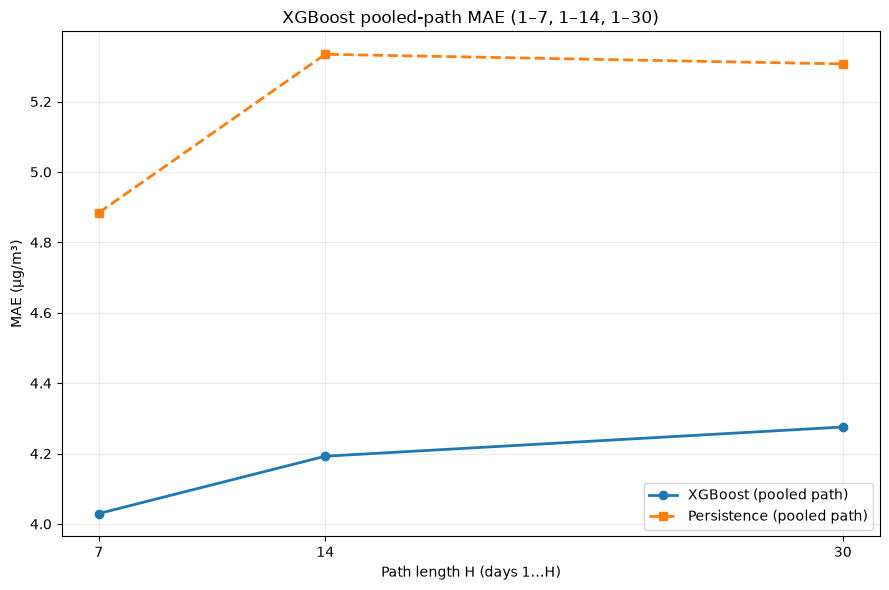

In [33]:
# ============================================================
# PLOT 1 — MAE: XGBOOST VS PERSISTENCE
# Changed: pooled path H in {7, 14, 30}, not day-h-only.
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["MAE"],
    marker="o",
    linewidth=2,
    label="XGBoost (pooled path)",
)

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["Persistence_MAE"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Persistence (pooled path)",
)

plt.xlabel("Path length H (days 1…H)")
plt.ylabel("MAE (µg/m³)")
plt.title("XGBoost pooled-path MAE (1–7, 1–14, 1–30)")

plt.xticks(PATH_HORIZONS)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


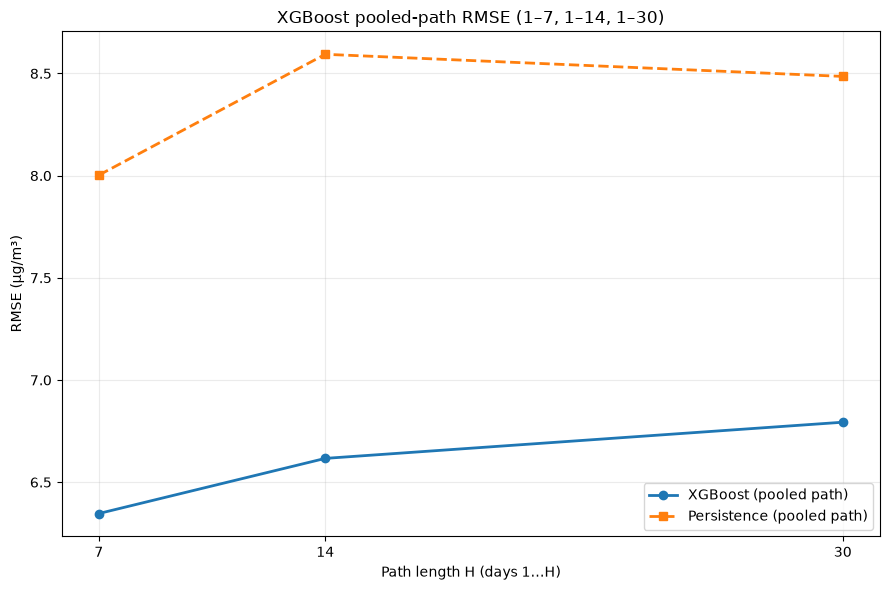

In [34]:
# ============================================================
# PLOT 2 — RMSE: XGBOOST VS PERSISTENCE
# Changed: pooled path H in {7, 14, 30}, not day-h-only.
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["RMSE"],
    marker="o",
    linewidth=2,
    label="XGBoost (pooled path)",
)

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["Persistence_RMSE"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Persistence (pooled path)",
)

plt.xlabel("Path length H (days 1…H)")
plt.ylabel("RMSE (µg/m³)")
plt.title("XGBoost pooled-path RMSE (1–7, 1–14, 1–30)")

plt.xticks(PATH_HORIZONS)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


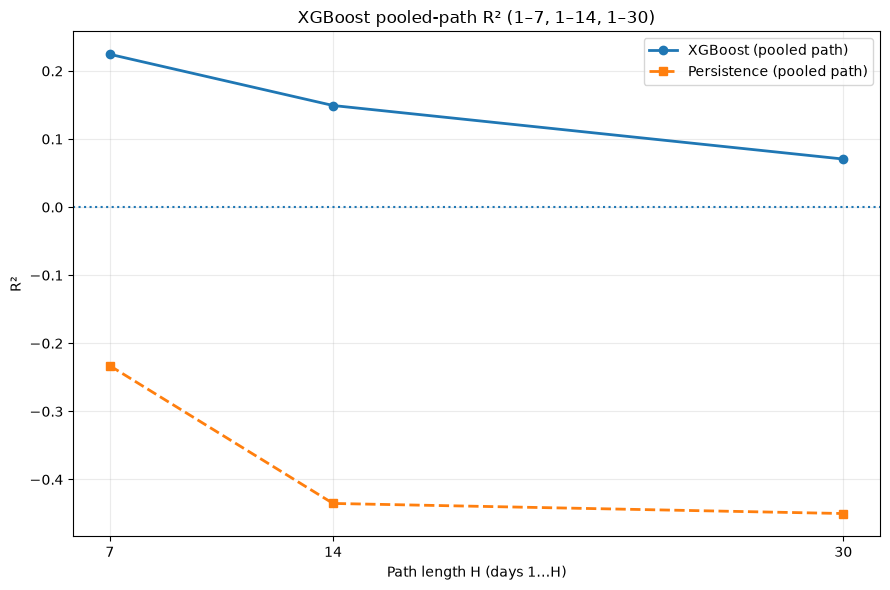

In [35]:
# ============================================================
# PLOT 3 — R² ACROSS PATH LENGTHS
# Changed: pooled path H in {7, 14, 30}, not day-h-only.
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["R2"],
    marker="o",
    linewidth=2,
    label="XGBoost (pooled path)",
)

plt.plot(
    path_results_df["Horizon_Days"],
    path_results_df["Persistence_R2"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Persistence (pooled path)",
)

plt.axhline(y=0, linestyle=":", linewidth=1.5)

plt.xlabel("Path length H (days 1…H)")
plt.ylabel("R²")
plt.title("XGBoost pooled-path R² (1–7, 1–14, 1–30)")

plt.xticks(PATH_HORIZONS)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


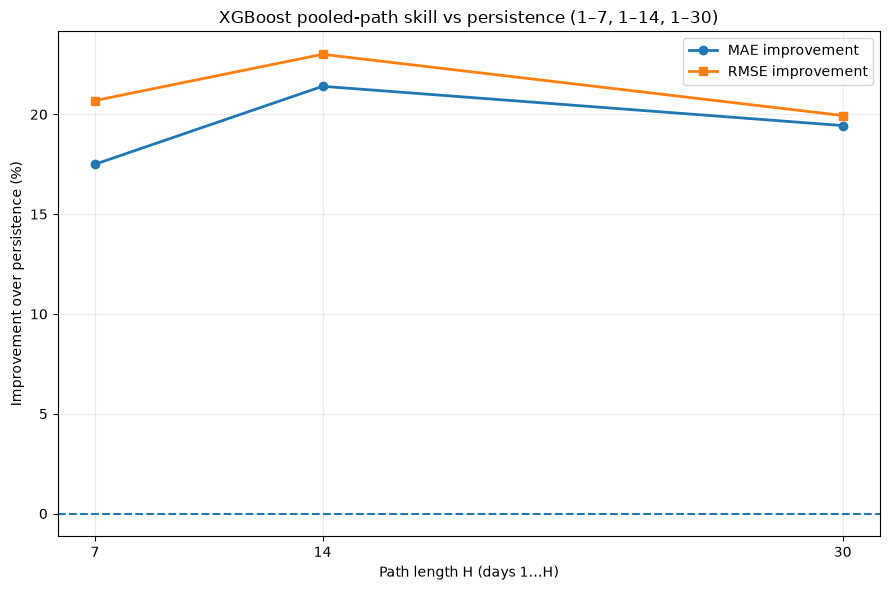

In [36]:
# ============================================================
# PLOT 4 — FORECAST SKILL OVER PERSISTENCE
# Changed: pooled path H in {7, 14, 30}, not day-h-only.
# ============================================================

mae_imp = (
    100.0
    * (path_results_df["Persistence_MAE"] - path_results_df["MAE"])
    / path_results_df["Persistence_MAE"]
)
rmse_imp = (
    100.0
    * (path_results_df["Persistence_RMSE"] - path_results_df["RMSE"])
    / path_results_df["Persistence_RMSE"]
)

plt.figure(figsize=(9, 6))

plt.plot(
    path_results_df["Horizon_Days"],
    mae_imp,
    marker="o",
    linewidth=2,
    label="MAE improvement",
)

plt.plot(
    path_results_df["Horizon_Days"],
    rmse_imp,
    marker="s",
    linewidth=2,
    label="RMSE improvement",
)

plt.axhline(y=0, linestyle="--", linewidth=1.5)

plt.xlabel("Path length H (days 1…H)")
plt.ylabel("Improvement over persistence (%)")
plt.title("XGBoost pooled-path skill vs persistence (1–7, 1–14, 1–30)")

plt.xticks(PATH_HORIZONS)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


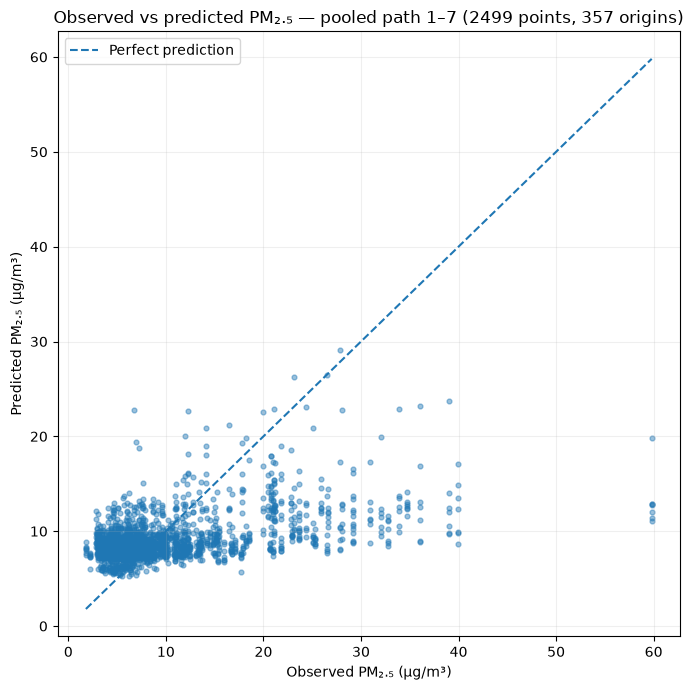

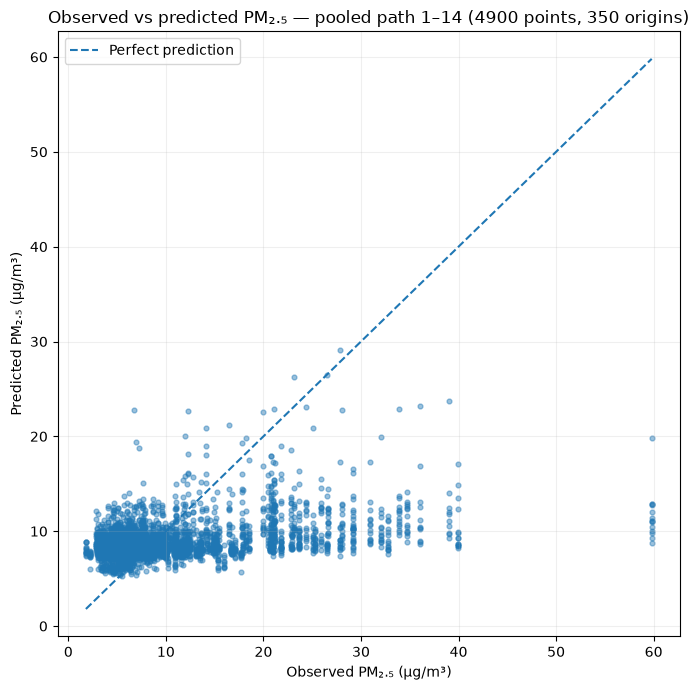

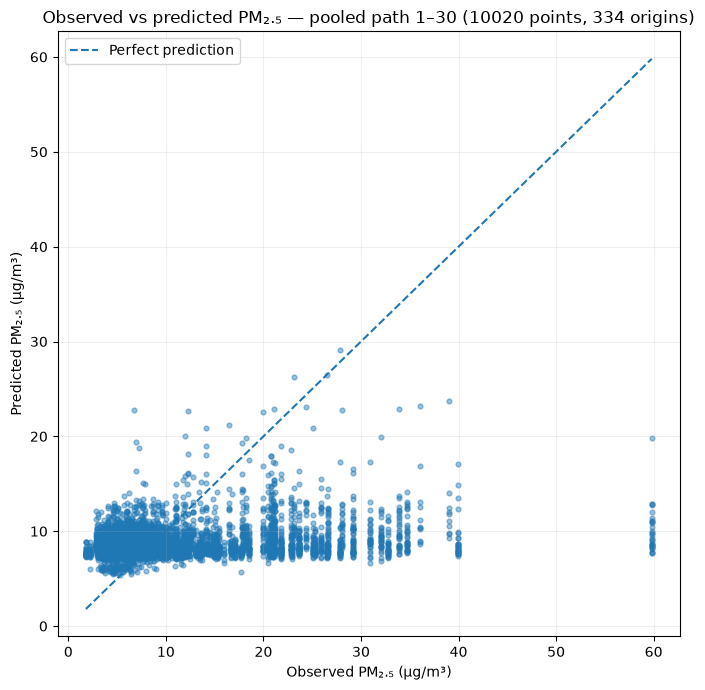

In [37]:
# ============================================================
# PLOT 6 — OBSERVED VS PREDICTED SCATTER
# Changed: one scatter per path H, stacking leads 1…H
# (matches the pooled-path metrics / neural notebooks).
# ============================================================

for H in PATH_HORIZONS:
    path_df = stack_pooled_path(predictions, H)
    actual = path_df["Actual_PM25"].to_numpy()
    predicted = path_df["Predicted_PM25"].to_numpy()
    lower = min(actual.min(), predicted.min())
    upper = max(actual.max(), predicted.max())

    plt.figure(figsize=(7, 7))
    plt.scatter(actual, predicted, alpha=0.45, s=12)
    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.5,
        label="Perfect prediction",
    )
    plt.xlabel("Observed PM₂.₅ (µg/m³)")
    plt.ylabel("Predicted PM₂.₅ (µg/m³)")
    plt.title(
        f"Observed vs predicted PM₂.₅ — pooled path 1–{H} "
        f"({len(path_df)} points, {path_df['Forecast_Origin'].nunique()} origins)"
    )
    plt.legend()
    plt.grid(alpha=0.20)
    plt.tight_layout()
    plt.show()


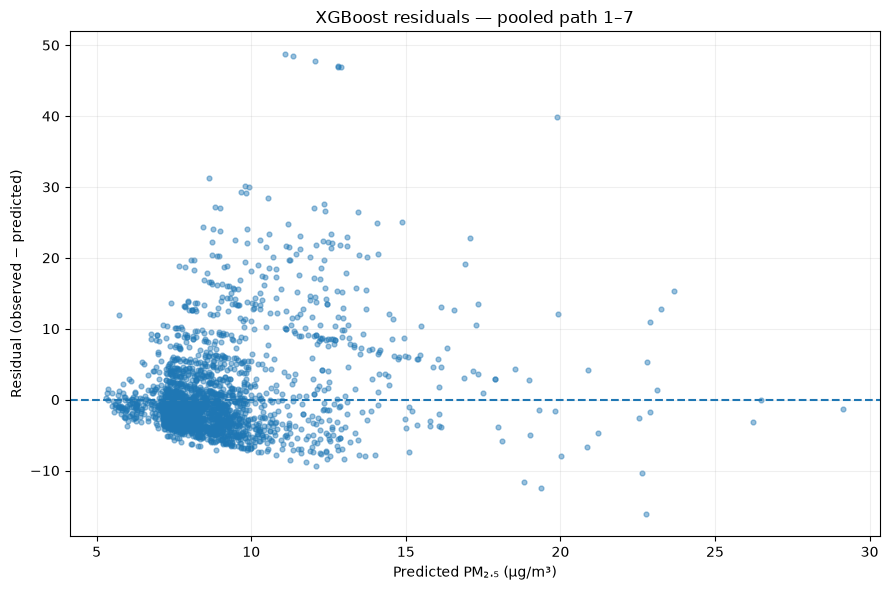

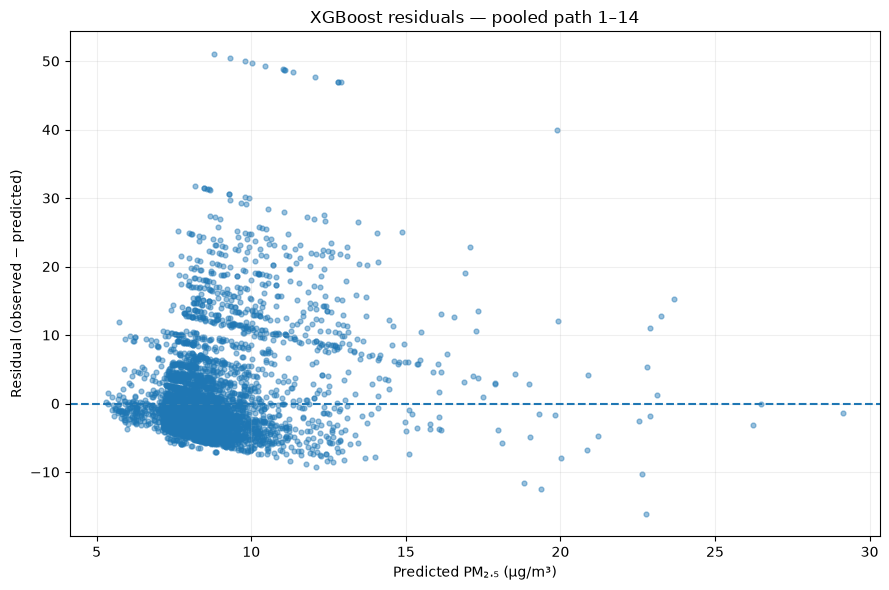

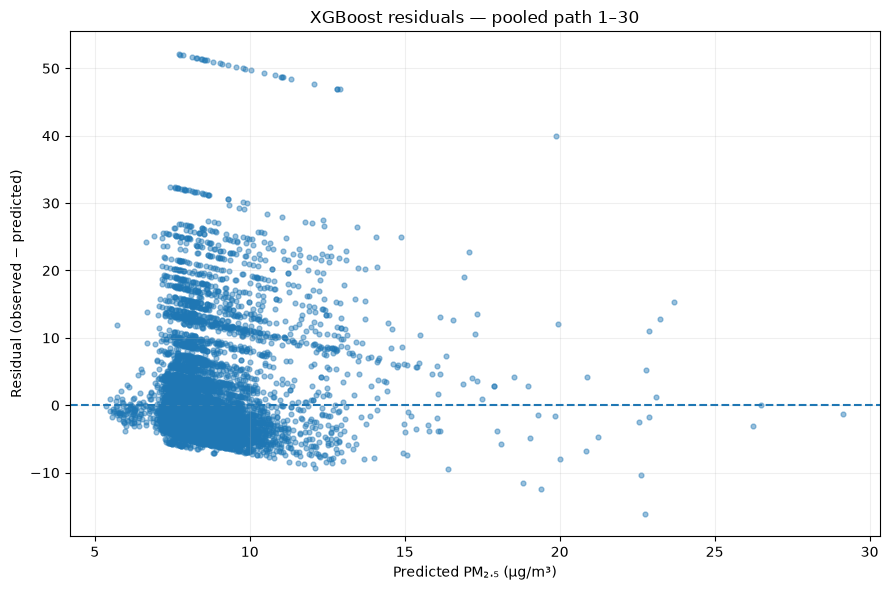

In [38]:
# ============================================================
# PLOT 7 — RESIDUAL DIAGNOSTICS
# Changed: residuals on the stacked path 1…H, not day h only.
# ============================================================

for H in PATH_HORIZONS:
    path_df = stack_pooled_path(predictions, H)
    residual = path_df["Actual_PM25"] - path_df["Predicted_PM25"]

    plt.figure(figsize=(9, 6))
    plt.scatter(path_df["Predicted_PM25"], residual, alpha=0.45, s=12)
    plt.axhline(y=0, linestyle="--", linewidth=1.5)
    plt.xlabel("Predicted PM₂.₅ (µg/m³)")
    plt.ylabel("Residual (observed − predicted)")
    plt.title(f"XGBoost residuals — pooled path 1–{H}")
    plt.grid(alpha=0.20)
    plt.tight_layout()
    plt.show()


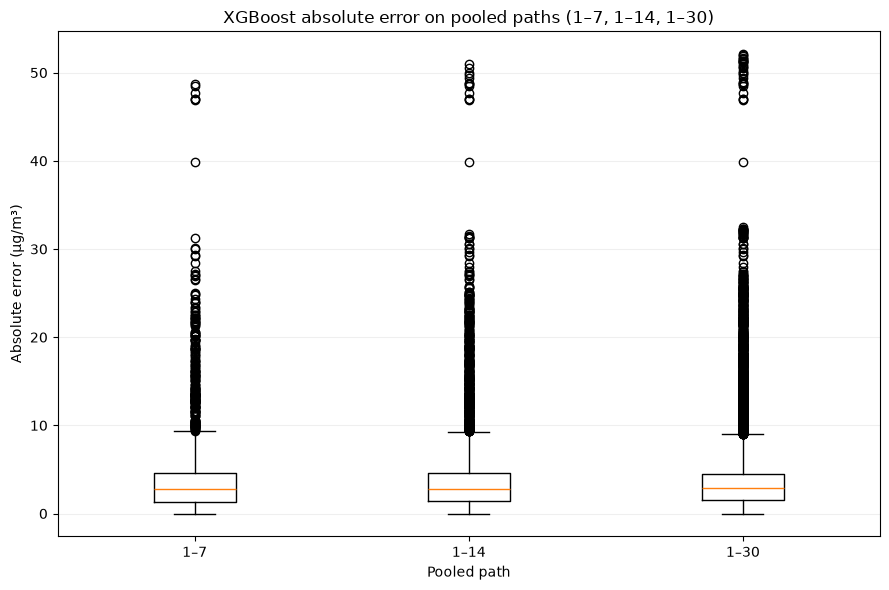

In [39]:
# ============================================================
# PLOT 8 — ABSOLUTE ERROR DISTRIBUTION
# Changed: one box per path length H (stacked 1…H), not 30 leads.
# ============================================================

error_data = []
labels = []

for H in PATH_HORIZONS:
    path_df = stack_pooled_path(predictions, H)
    absolute_error = np.abs(
        path_df["Actual_PM25"] - path_df["Predicted_PM25"]
    )
    error_data.append(absolute_error.to_numpy())
    labels.append(f"1–{H}")

plt.figure(figsize=(9, 6))
plt.boxplot(error_data, tick_labels=labels, showfliers=True)
plt.xlabel("Pooled path")
plt.ylabel("Absolute error (µg/m³)")
plt.title("XGBoost absolute error on pooled paths (1–7, 1–14, 1–30)")
plt.grid(axis="y", alpha=0.20)
plt.tight_layout()
plt.show()


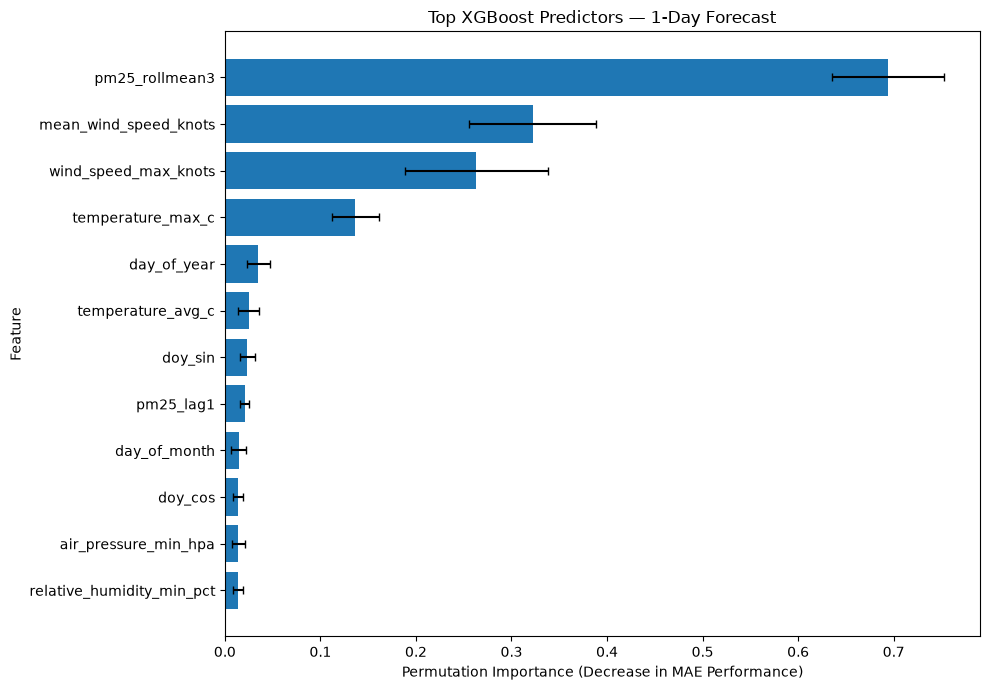

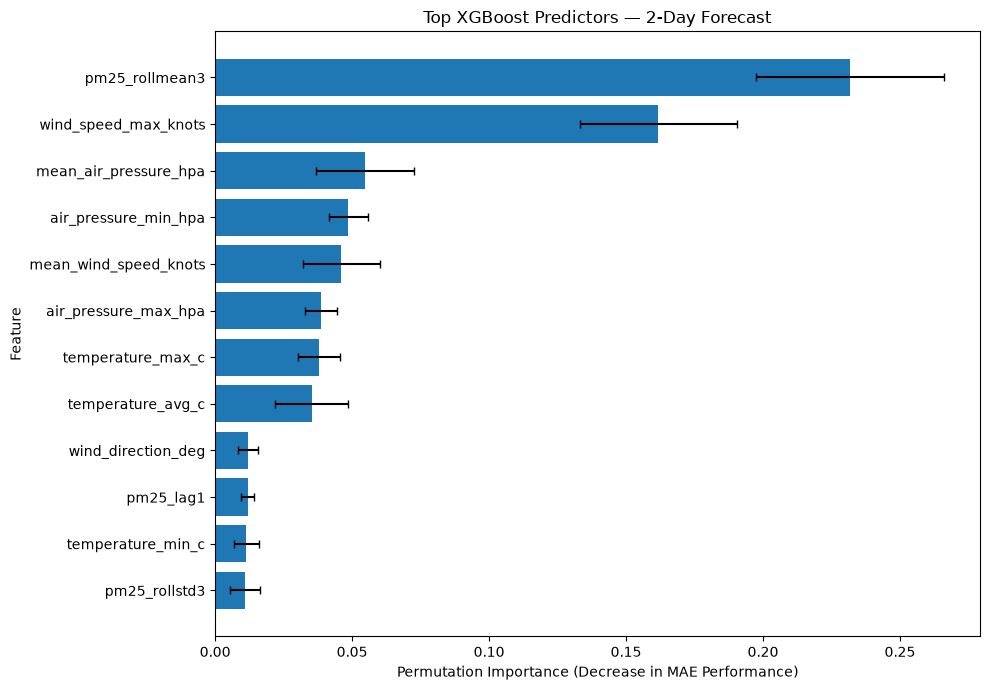

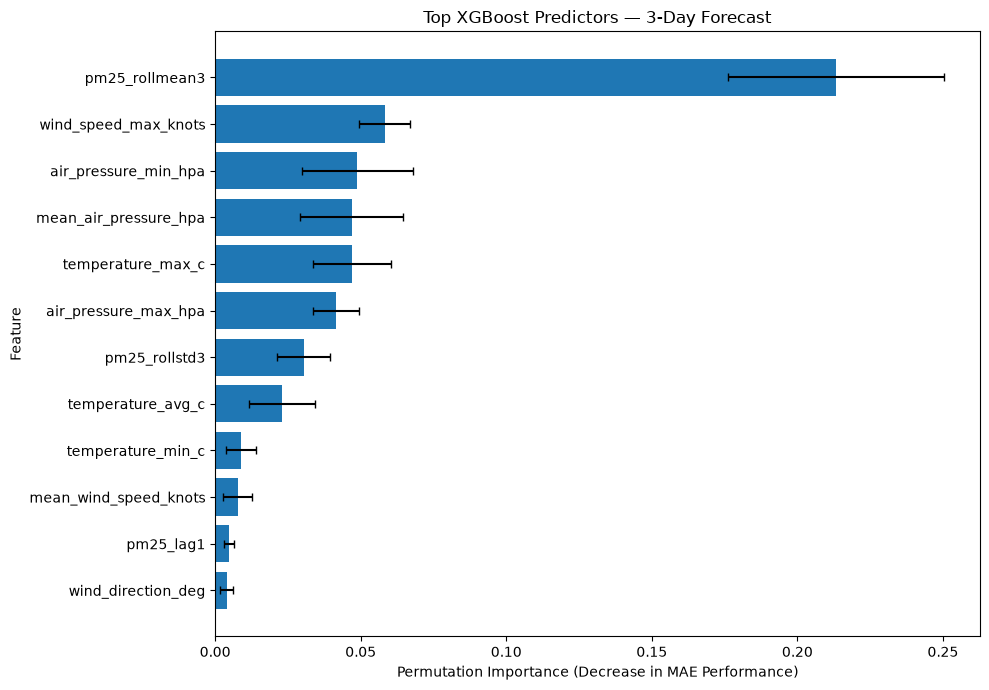

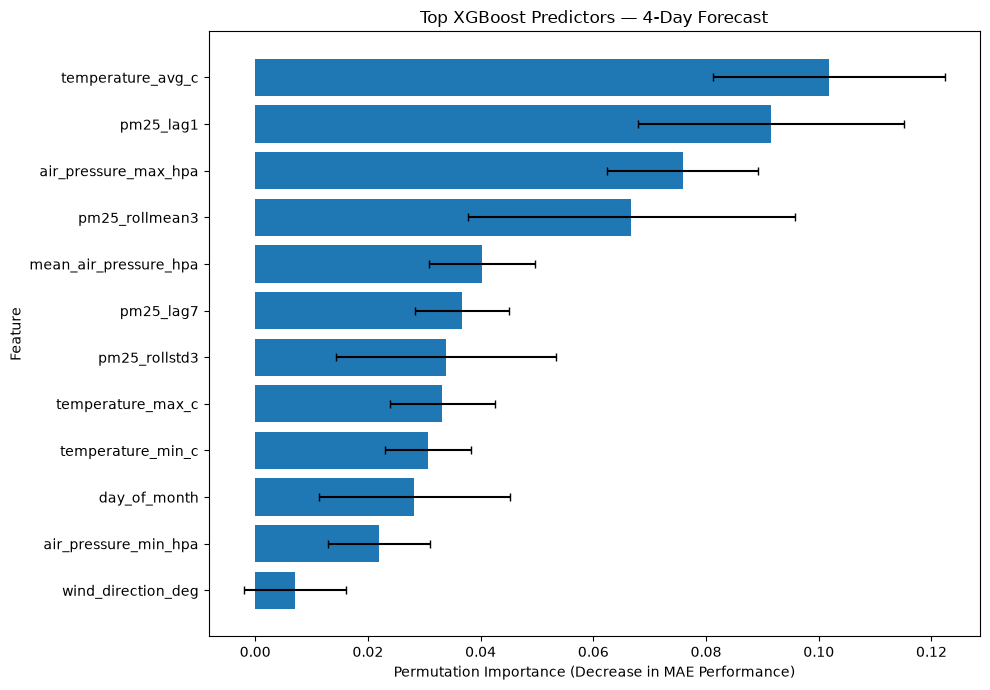

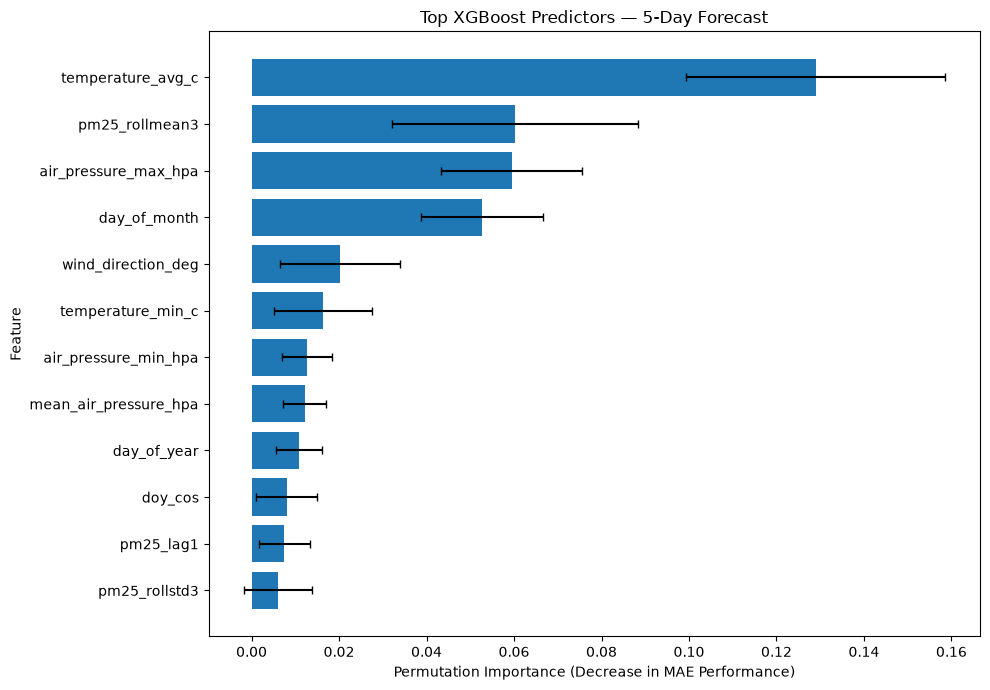

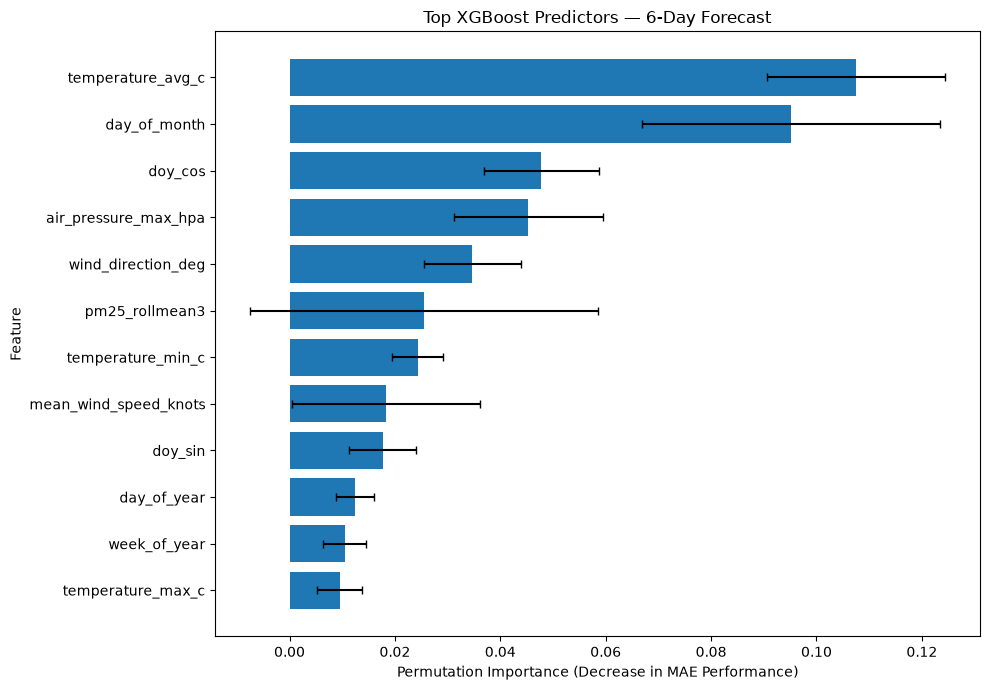

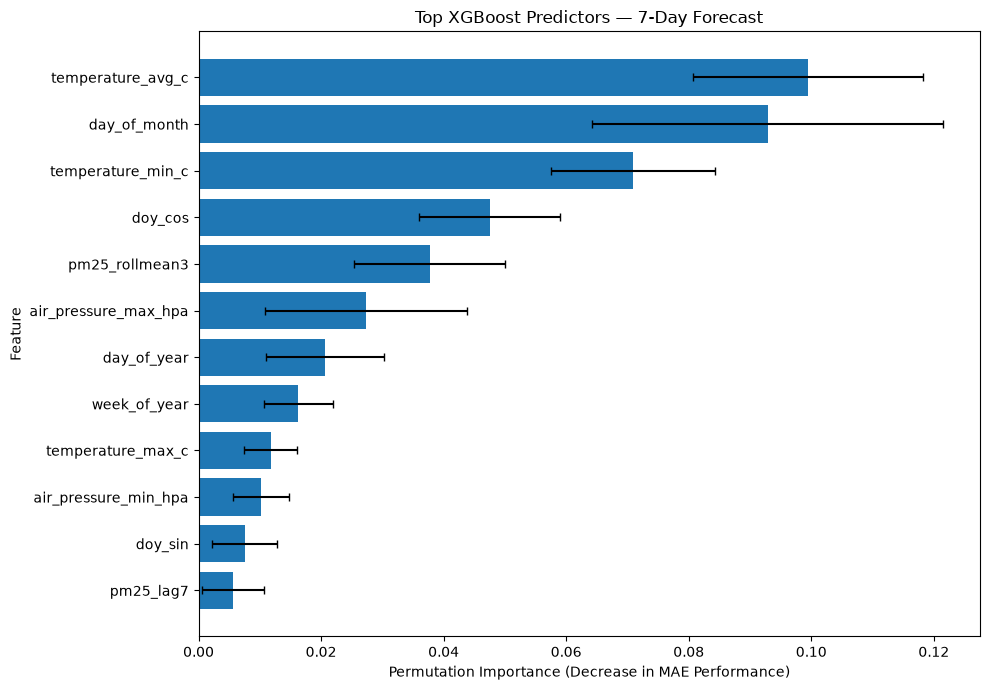

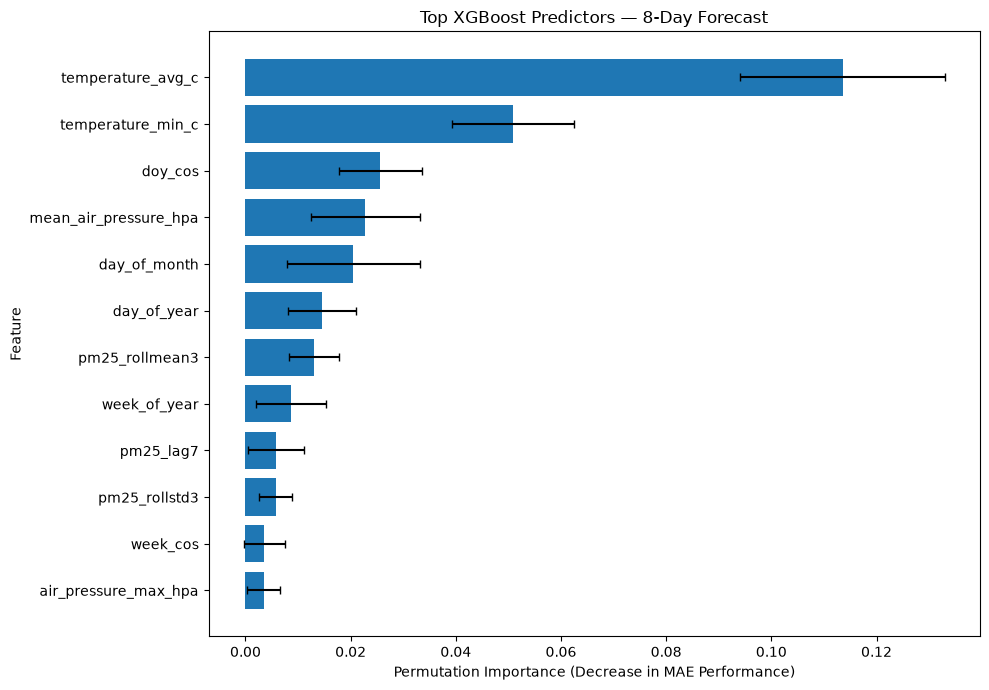

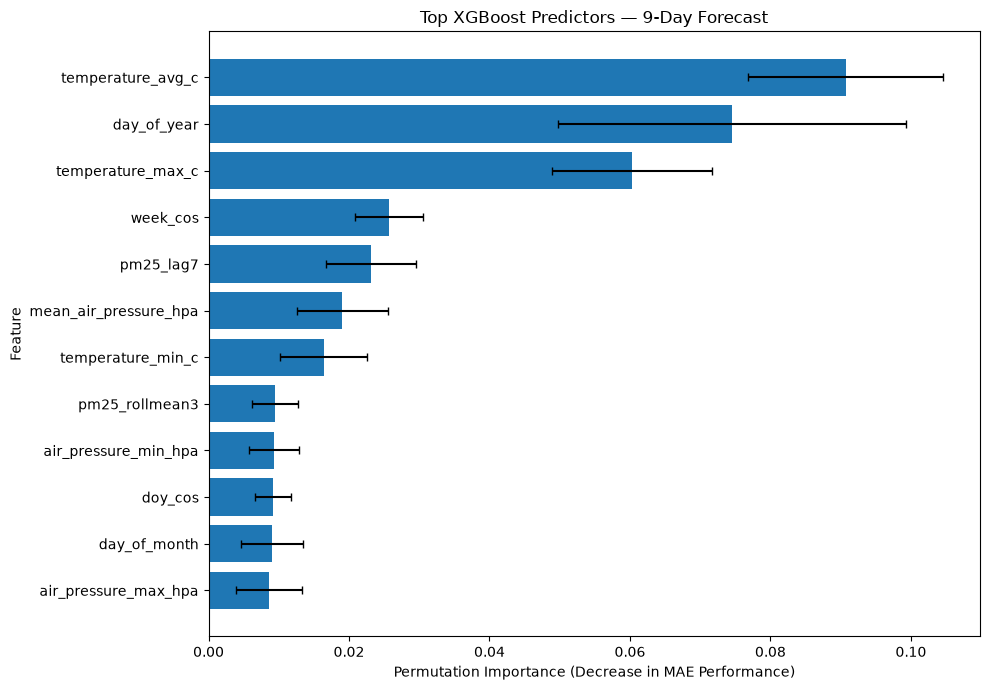

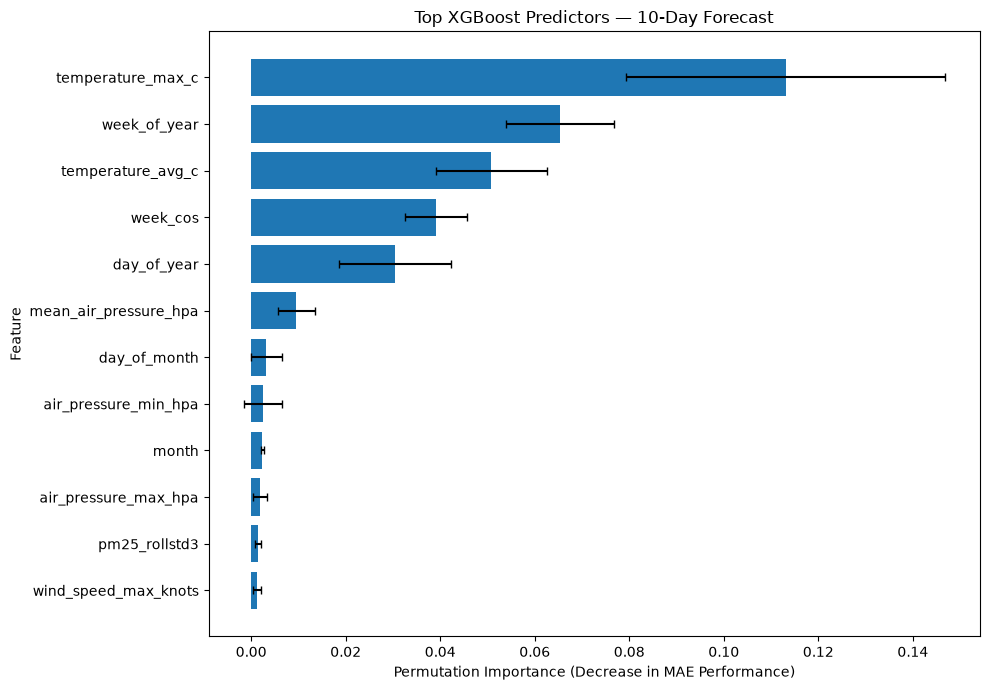

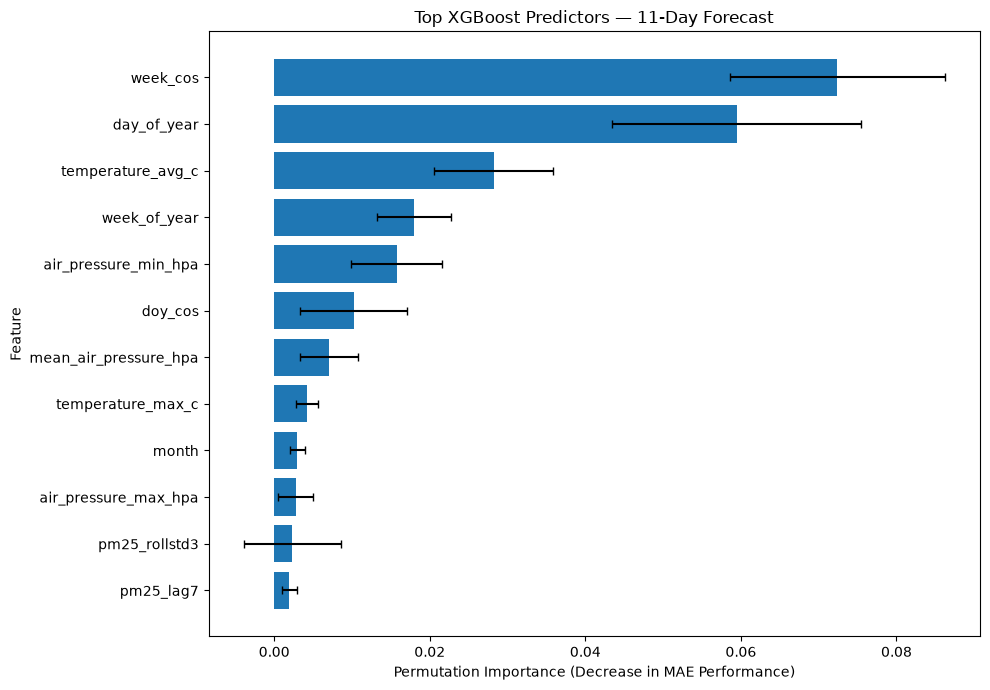

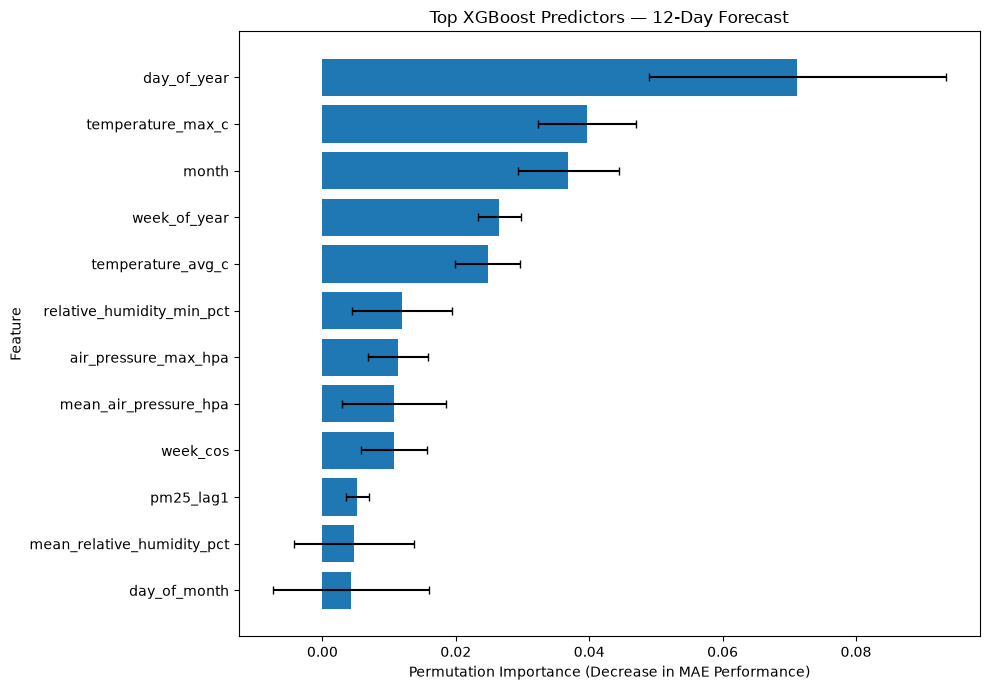

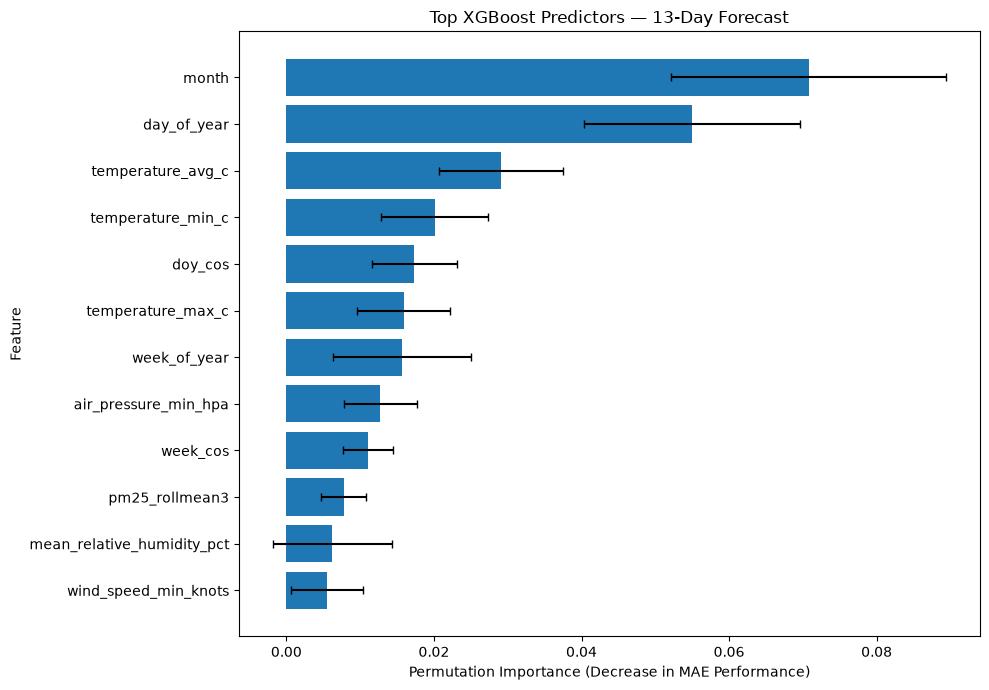

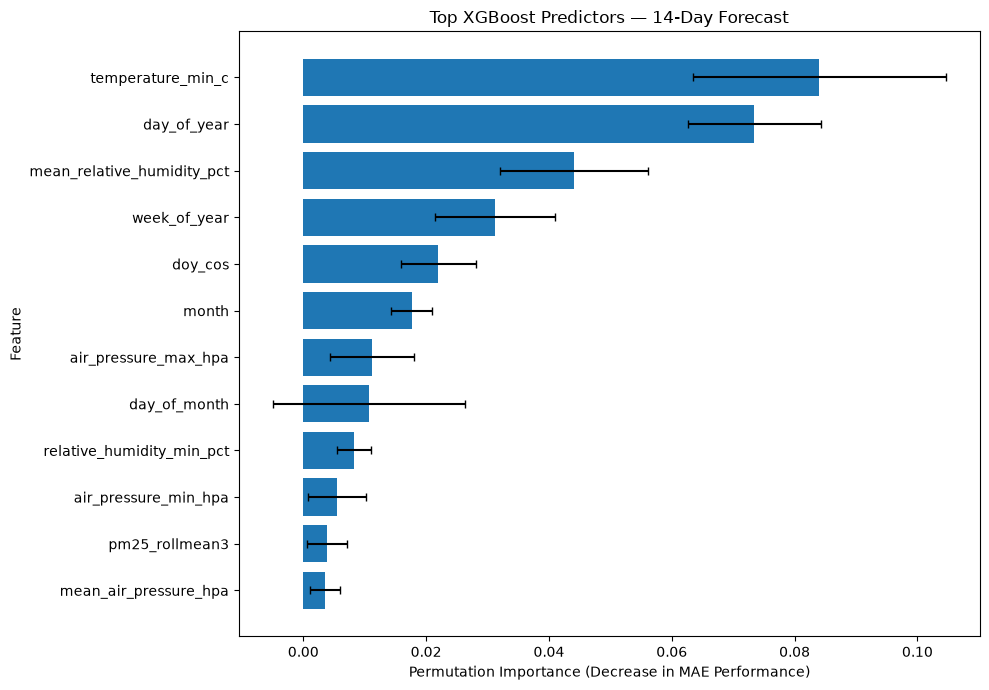

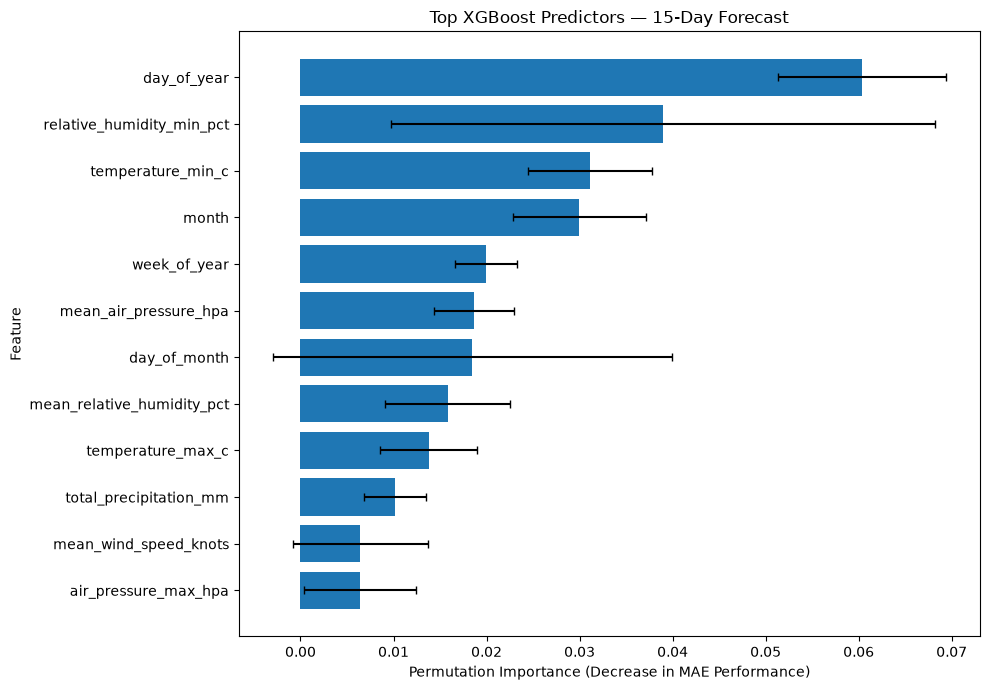

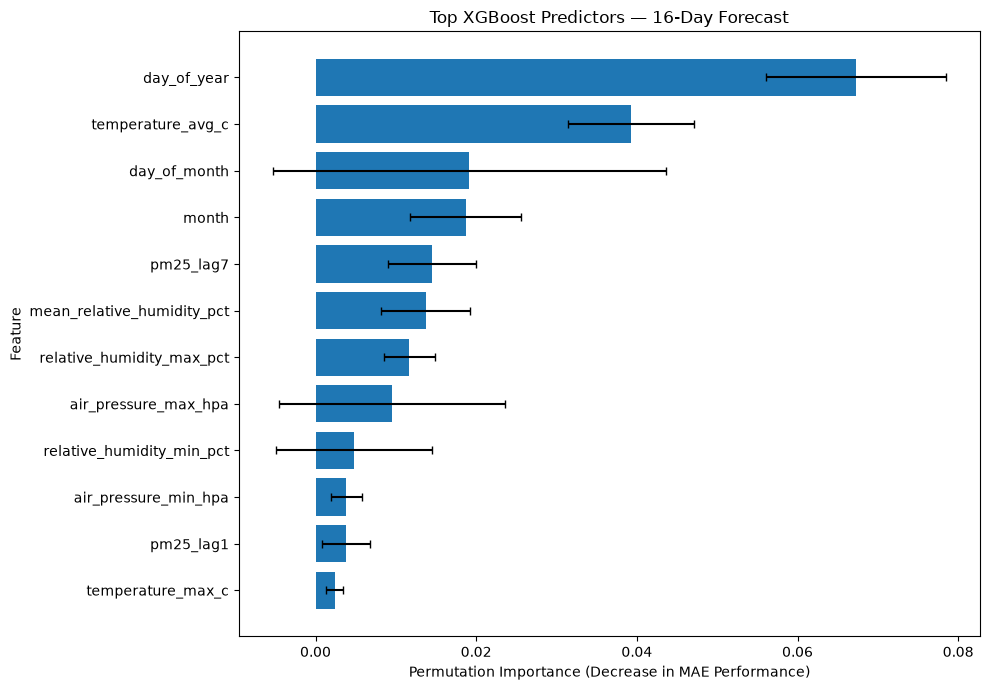

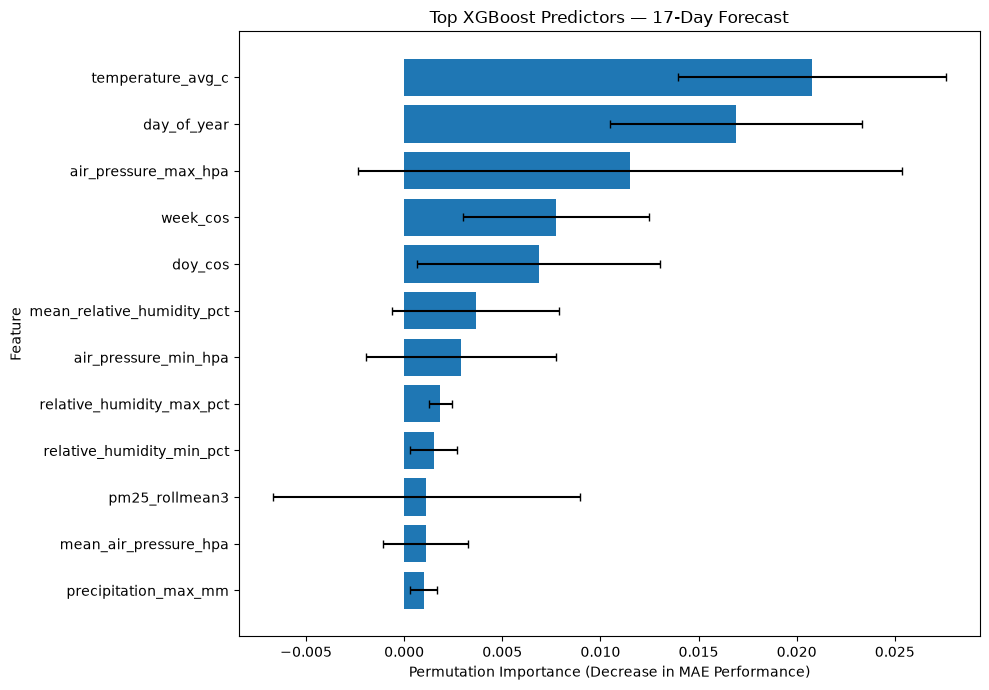

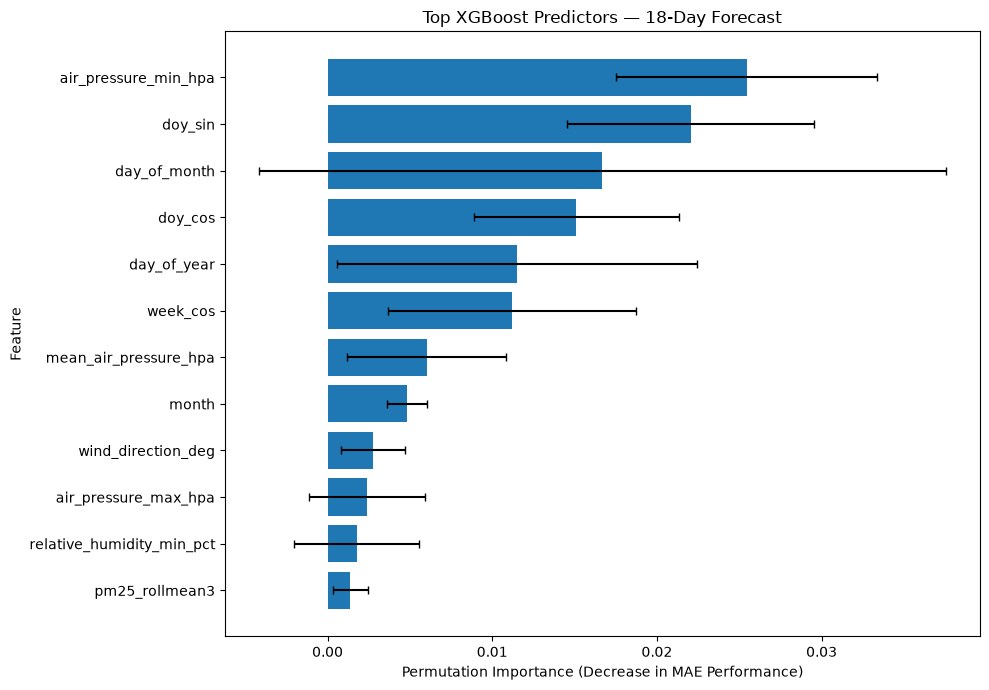

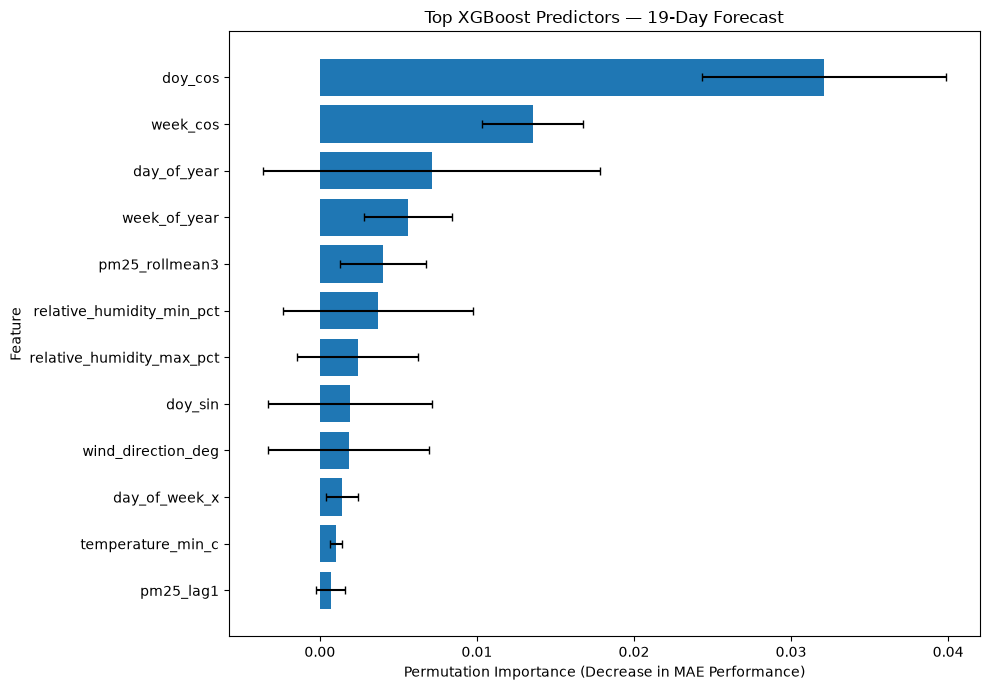

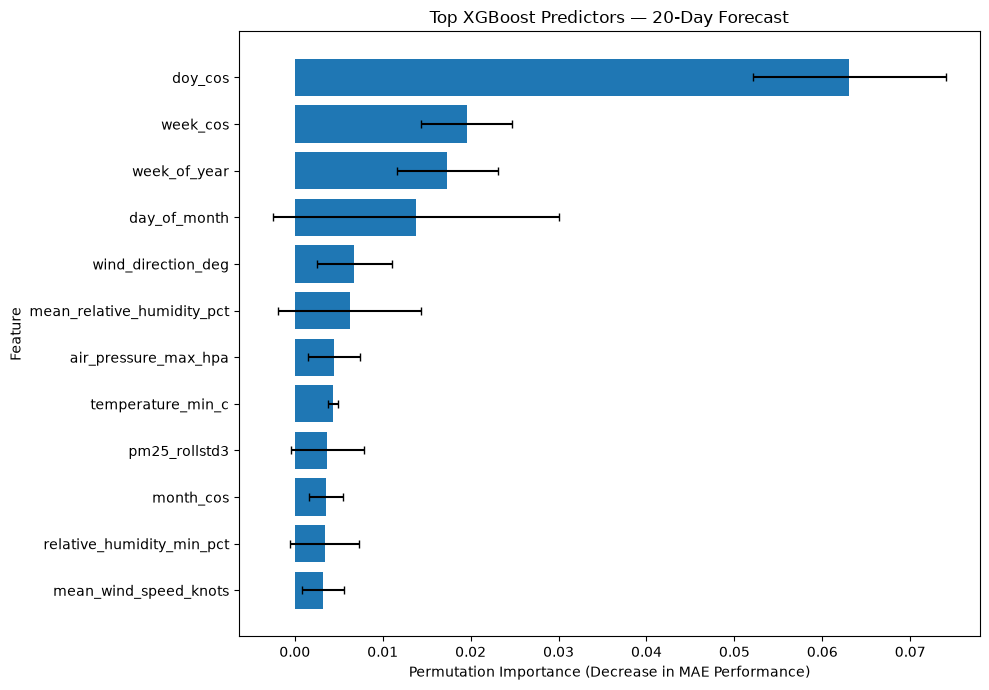

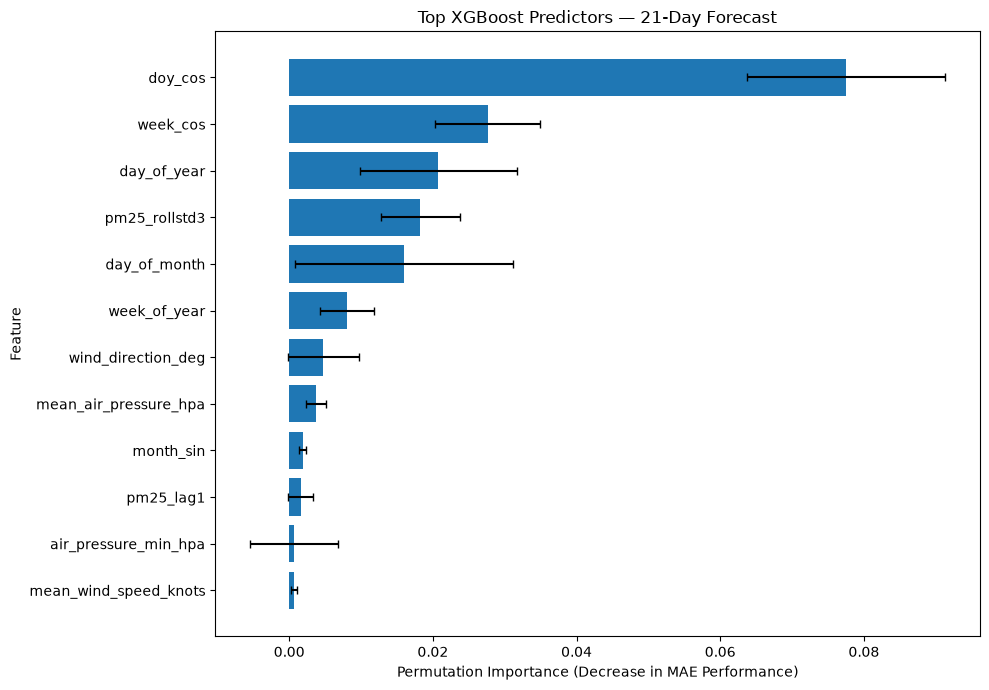

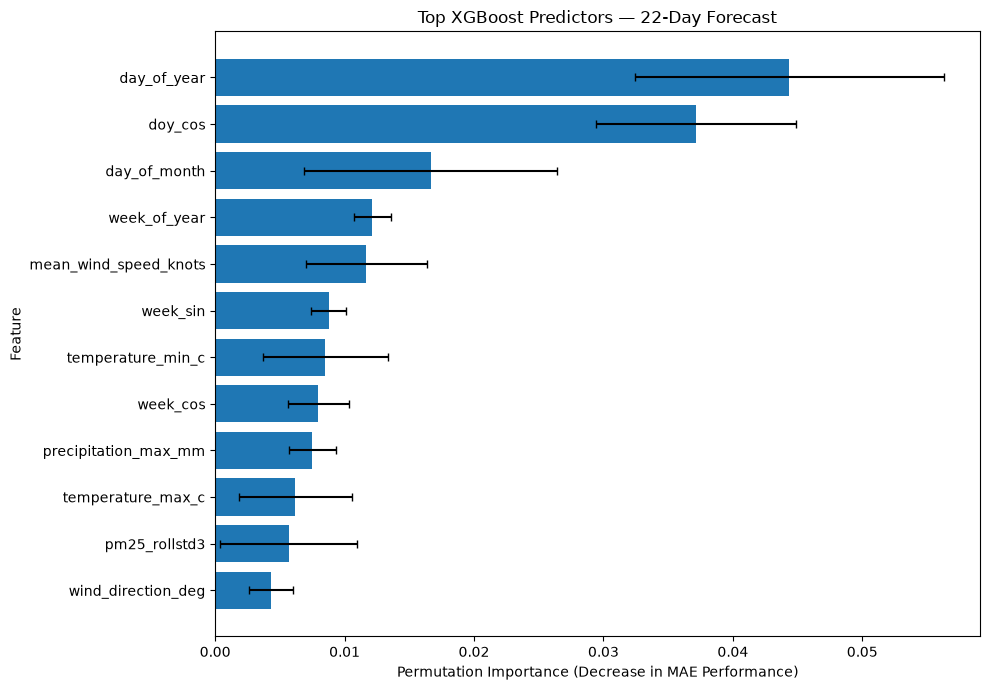

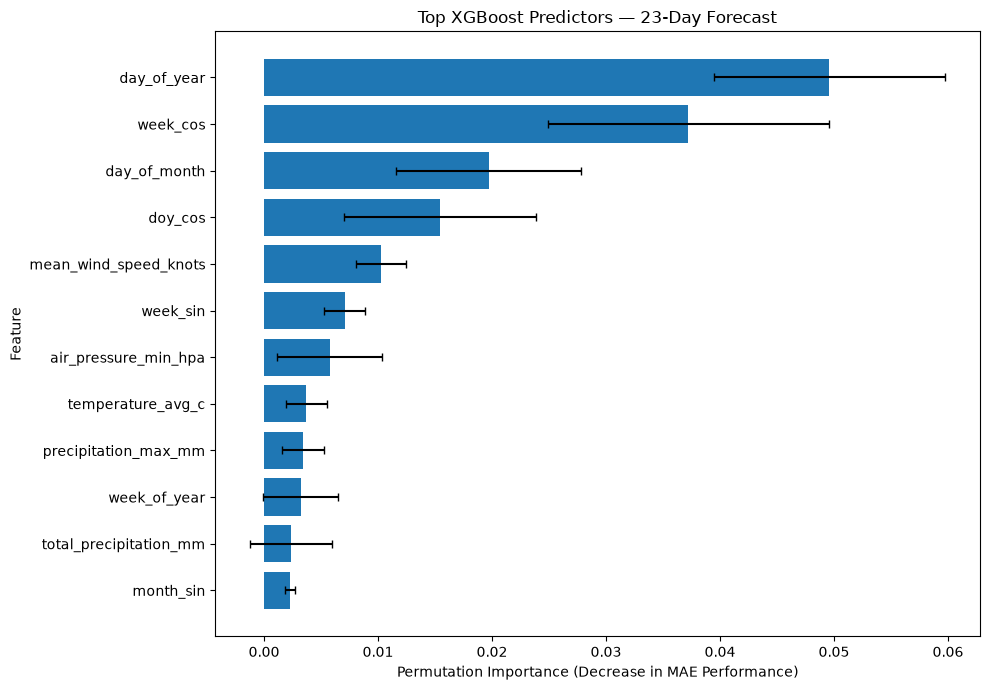

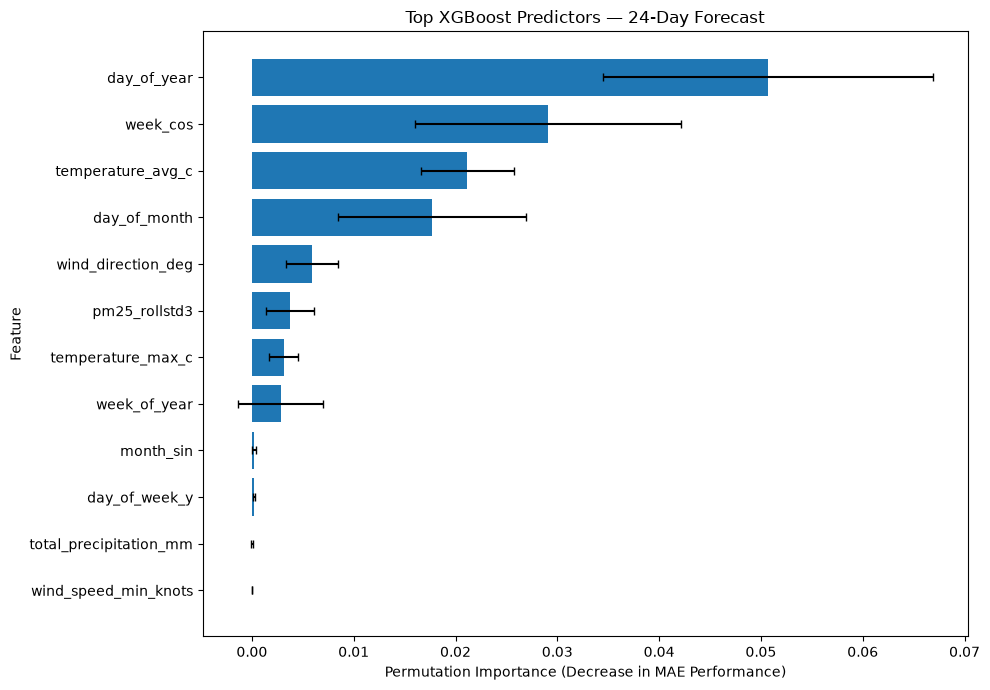

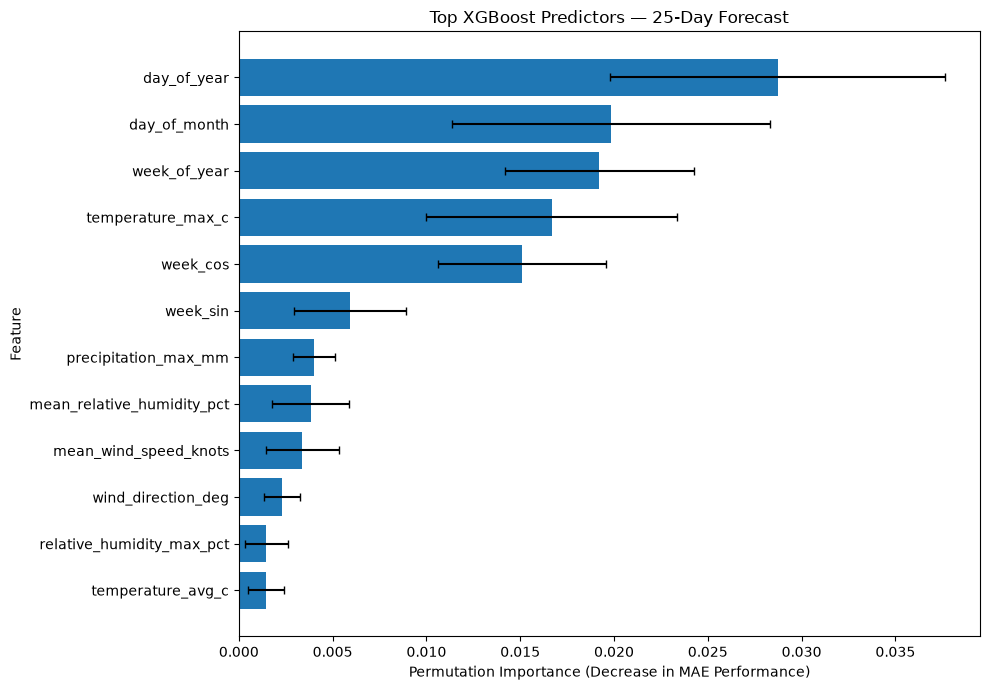

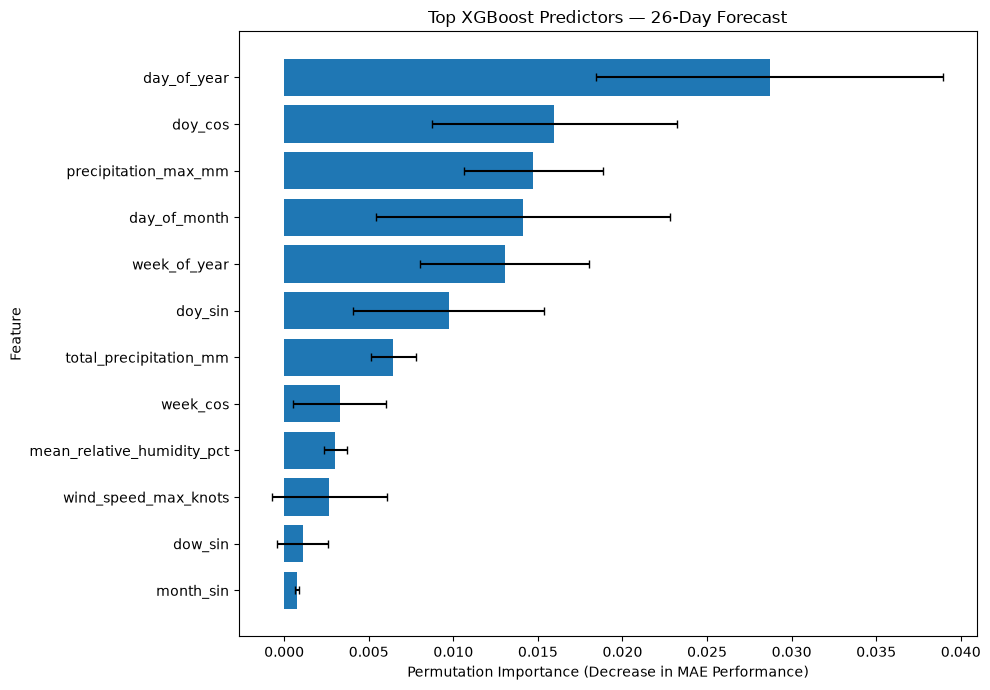

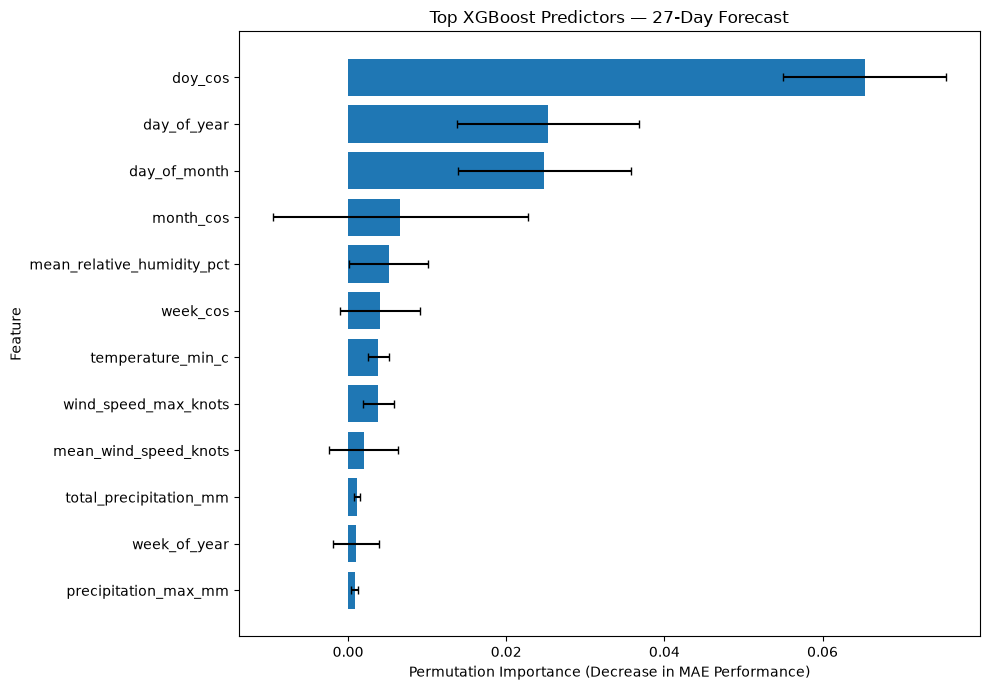

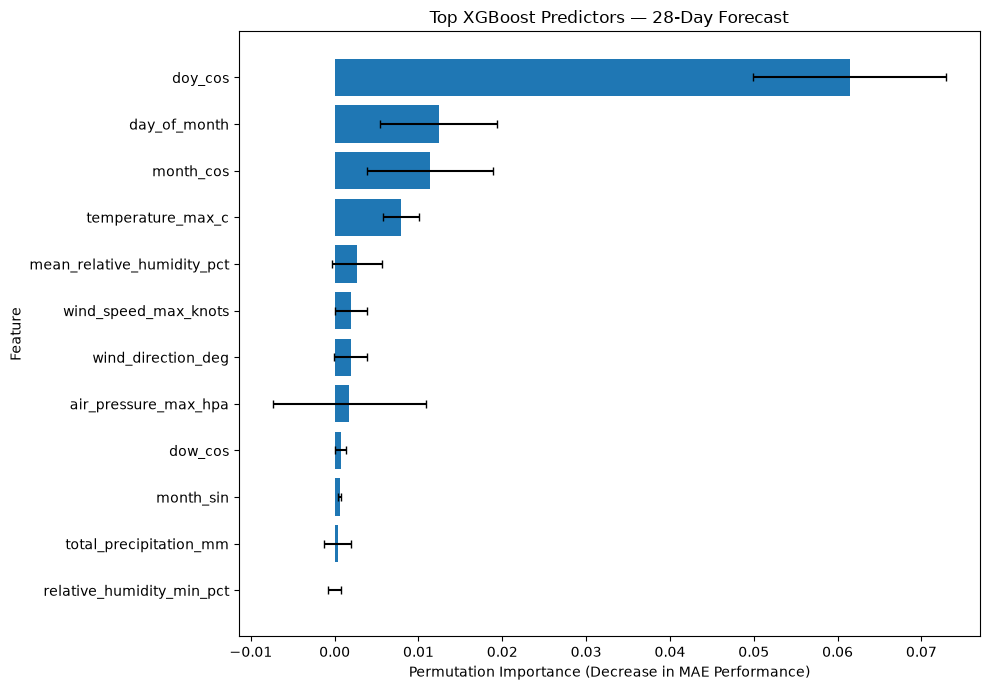

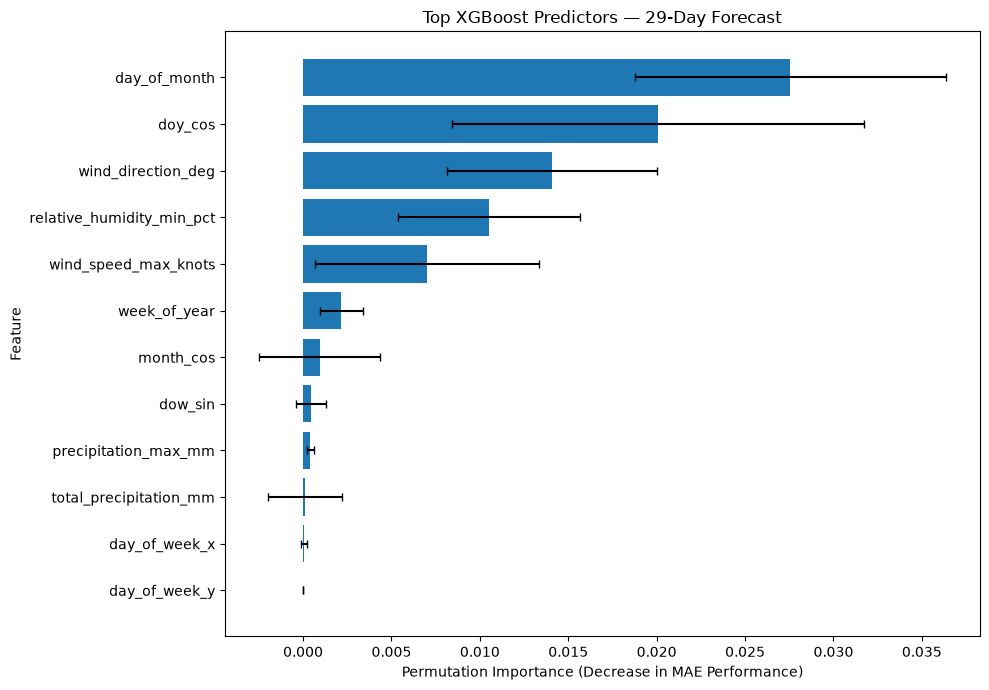

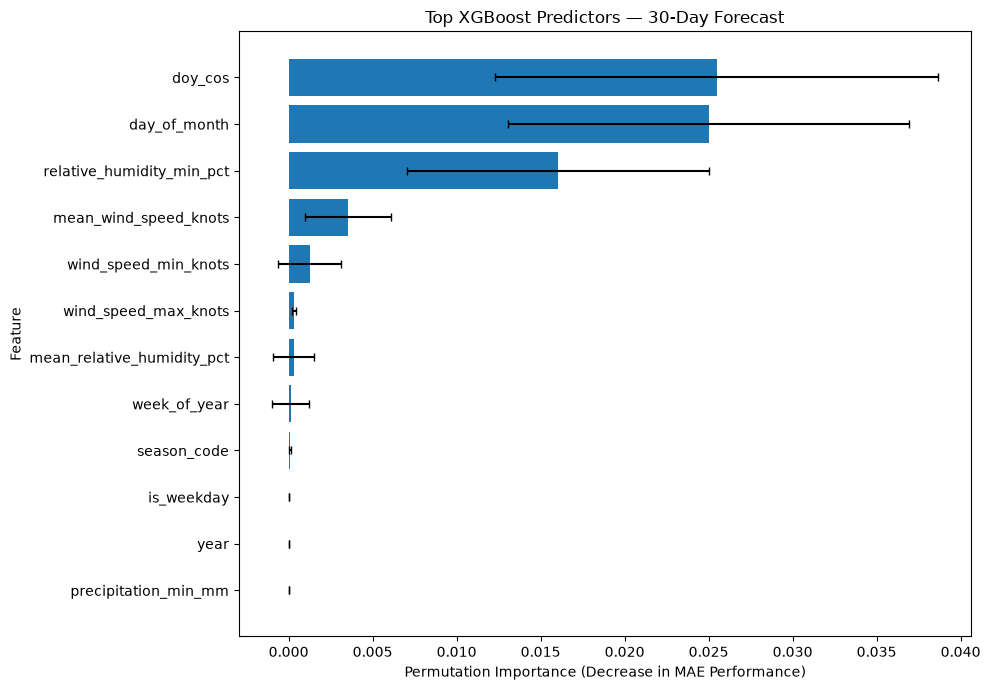

In [40]:
# Changed: left as per-lead plots. Permutation importance is defined
# on one direct model, not on a stacked 1…H path.
# ============================================================
# PLOT 9 — PERMUTATION FEATURE IMPORTANCE
# ============================================================

for horizon in FORECAST_HORIZONS:

    importance_df = (
        feature_importances[horizon]
        .head(12)
        .sort_values(
            "Importance_Mean",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance_Mean"],
        xerr=importance_df["Importance_STD"],
        capsize=3
    )

    plt.xlabel(
        "Permutation Importance "
        "(Decrease in MAE Performance)"
    )

    plt.ylabel("Feature")

    plt.title(
        f"Top XGBoost Predictors — "
        f"{horizon}-Day Forecast"
    )

    plt.tight_layout()
    plt.show()


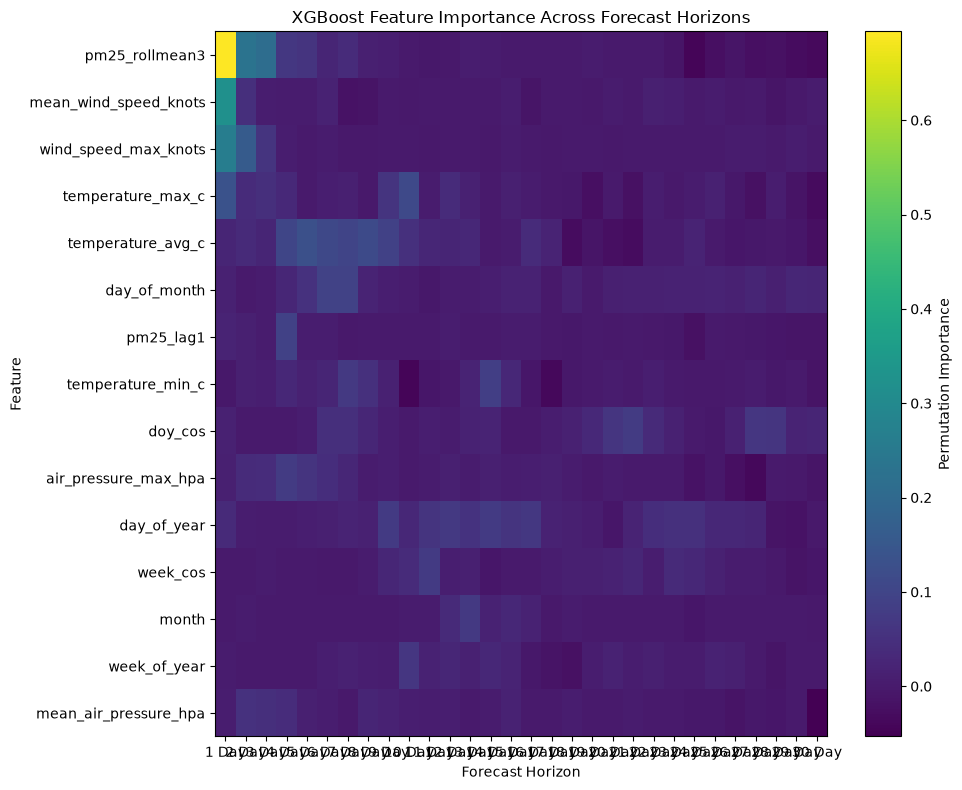

In [41]:
# Changed: heatmap still uses each lead's own model. Not a pooled path.
# ============================================================
# PLOT 10 — FEATURE IMPORTANCE ACROSS HORIZONS
# ============================================================

importance_matrix = pd.DataFrame()

for horizon in FORECAST_HORIZONS:

    temp = (
        feature_importances[horizon]
        .set_index("Feature")["Importance_Mean"]
    )

    importance_matrix[
        f"{horizon} Day"
    ] = temp


top_features = (
    importance_matrix
    .max(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

heatmap_data = importance_matrix.loc[
    top_features
]

plt.figure(figsize=(10, 8))

image = plt.imshow(
    heatmap_data.values,
    aspect="auto"
)

plt.colorbar(
    image,
    label="Permutation Importance"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Feature")

plt.title(
    "XGBoost Feature Importance "
    "Across Forecast Horizons"
)

plt.tight_layout()
plt.show()


In [42]:
# ============================================================
# SAVE FINAL XGBOOST RESULTS
# ============================================================

results_df.to_csv(
    RESULTS_DIR /
    "xgboost_multi_horizon_results.csv",
    index=False
)

importance_matrix.to_csv(
    RESULTS_DIR /
    "xgboost_feature_importance_across_horizons.csv"
)

print("Final XGBoost results saved successfully.")

Final XGBoost results saved successfully.
